# Final Models: InSeq/OutSeq and Odor Identity Classification (All 5 Rats)

**What this notebook is.** This is the final, presentation-ready notebook for the project. It pulls
together the winning windows found in notebooks 022 (InSeq/OutSeq) and 023 (Odor Identity), and for
each one:

1. Shows what the underlying brain data actually looks like (raw LFP traces, filtered "brainwave"
   bands, band power, and time-frequency spectrograms), so the audience sees the signal before seeing
   any classifier output.
2. Trains and rigorously evaluates the final model for **all 5 rats** (repeated cross-validation,
   AUC, permutation test -- same rigor as notebooks 021-023).
3. Shows confusion matrices **one rat at a time** (own figure each), so each one can be dropped
   straight into a slide.
4. Shows a **combined confusion matrix** for each task, built by **summing the raw trial counts**
   across all 5 rats (not averaging percentages), so it reflects the total pool of trials actually
   evaluated.
5. Looks inside the model itself: which frequency band's logistic-regression coefficient ("beta")
   is doing the most work for each task, and in which direction -- the core interpretability question
   for this project.

**Two classification tasks, two training windows (winners from notebooks 022/023):**

| Task | Reference event | Offset | Length | Classes |
|---|---|---|---|---|
| InSeq vs. OutSeq | Poke-Out | -250 ms | 1000 ms | 2 (OutSeq / InSeq) |
| Odor Identity | Poke-In | 0 ms | 1500 ms | 5 (A / B / C / D / E), InSeq trials only |

**A note on the InSeq/OutSeq training window, for the record.** The window above (Poke-Out -250 to
+750ms) is what notebook 022's search selected and what Section 4's "official" results are built on. It
was flagged in the most recent meeting that a window built this way is not ideal for a *predictive*
story: because it extends to +750ms *after* the rat has already left the port, a "successful"
classification could partly just be detecting the withdrawal movement itself rather than a genuine
pre-decision brain state. **Section 4d now runs the actual revised search**: a proper sliding-window
search constrained so every candidate ends at or before Poke-Out, selected with the same Mitt/Buchanan
maximin rule as everywhere else, then fully re-evaluated. Once that section has been run, compare its
numbers to Section 4's directly (Section 4d's head-to-head cell does this) and, if they hold up,
promote Section 4d's window to be the official one -- see Section 4d for exactly what that involves.
The 5-way Odor Identity window (Poke-In, 0-1500ms) does not have this issue, since it is anchored to the
start of the trial rather than to a behavioral response.

**Assumed project layout** (same as every other notebook in this project): this notebook lives in the
`notebooks/` folder, with `../data/raw/<session>/` holding the four `.npz` files per rat and
`../src/preprocessing.py` providing `build_labels` and `get_sampling_rate`.


## 1. Setup

In [1]:
import sys
sys.path.append('..')

import os
import json as _json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from src.preprocessing import build_labels, get_sampling_rate

RAW_DIR = Path('../data/raw')
SESSION_DIRS = sorted([p for p in RAW_DIR.iterdir() if p.is_dir()])
RAT_LABELS = {s.name: s.name.split('_')[1].capitalize() for s in SESSION_DIRS}
PRIORITY_RATS = ['080718_mitt', '090420_buchanan']  # Mitt & Buchanan, per advisor priority

FIG_DIR = Path('../outputs/figures')
LOG_DIR = Path('../outputs/logs')
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

BANDS = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}

# Winning windows, carried over from notebooks 022 (InSeq/OutSeq) and 023 (Odor Identity)
INSEQ_WINDOW = {'name': 'pokeout_-250_1000', 'reference': 'pokeout', 'offset_ms': -250, 'length_ms': 1000}
ODOR_WINDOW  = {'name': 'pokein_0_1500',     'reference': 'pokein',  'offset_ms': 0,    'length_ms': 1500}

N_PERMUTATIONS = 99
RAT_COLOR = plt.cm.tab10(np.linspace(0, 1, len(SESSION_DIRS)))

print(f"Found {len(SESSION_DIRS)} sessions: {[s.name for s in SESSION_DIRS]}")
print(f"InSeq/OutSeq window : {INSEQ_WINDOW}")
print(f"Odor Identity window: {ODOR_WINDOW}")


Found 5 sessions: ['080718_mitt', '081106_barat', '090212_stella', '090212_superchris', '090420_buchanan']
InSeq/OutSeq window : {'name': 'pokeout_-250_1000', 'reference': 'pokeout', 'offset_ms': -250, 'length_ms': 1000}
Odor Identity window: {'name': 'pokein_0_1500', 'reference': 'pokein', 'offset_ms': 0, 'length_ms': 1500}


### Helper functions

Same window-extraction / feature-building logic used in notebooks 020-023, collected here in one
place since this notebook uses it for both the EDA visualizations and the final models.

In [2]:
def find_pokeout_idx(bvr_data, bvr_keys, timebin, trial_idx):
    """For each trial's Poke-In sample, find the first PokeEvents entry strictly between it and the
    NEXT trial's Poke-In (the notebook-020 fix that prevents leaking into the next trial)."""
    poke_events_row = bvr_data[bvr_keys.index('PokeEvents')]
    poke_event_idx = np.where(poke_events_row != 0)[0]
    pokeout_idx = np.full(len(trial_idx), -1, dtype=np.int64)
    for i, t in enumerate(trial_idx):
        next_bound = trial_idx[i + 1] if i + 1 < len(trial_idx) else len(timebin)
        candidates = poke_event_idx[(poke_event_idx > t) & (poke_event_idx < next_bound)]
        if len(candidates) > 0:
            pokeout_idx[i] = candidates[0]
    return pokeout_idx


def extract_window(lfp_data, timebin, ref_idx, offset_ms, length_ms, target_samples):
    """Cut [ref_time + offset_ms, + length_ms] out of the LFP, resampled to a fixed sample count so
    every trial's feature vector has the same length regardless of tiny sampling-rate jitter."""
    if ref_idx < 0:
        return None
    ref_time = timebin[ref_idx]
    start_time = ref_time + offset_ms / 1000
    end_time = start_time + length_ms / 1000
    if start_time < timebin[0] or end_time > timebin[-1]:
        return None
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    if end_idx - start_idx < 2:
        return None
    raw_window = lfp_data[:, start_idx:end_idx]
    n_channels, n_raw = raw_window.shape
    old_x = np.linspace(0, 1, n_raw)
    new_x = np.linspace(0, 1, target_samples)
    resampled = np.zeros((n_channels, target_samples))
    for ch in range(n_channels):
        resampled[ch] = np.interp(new_x, old_x, raw_window[ch])
    return resampled


def band_power_features(windows, fs, bands):
    """FFT-based power-per-band, per channel. Returns (n_trials, n_channels * n_bands)."""
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)
    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}
    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features))
    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            col += 1
    return X


def load_session(session_dir):
    """Load bvr + lfp for one session, plus derived timebin/fs/labels/pokeout, all in one dict."""
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']
    lfp_keys = lfp['keys'].tolist()  # real electrode/tetrode names, e.g. 'T1_LFP_Raw' -- used for plot labels
    timebin = bvr_data[bvr_keys.index('TimeBin')]
    fs = get_sampling_rate(bvr_data, bvr_keys)
    labels = build_labels(bvr_data, bvr_keys)
    pokeout_idx = find_pokeout_idx(bvr_data, bvr_keys, timebin, labels['trial_idx'])
    return {
        'name': session_name, 'bvr_data': bvr_data, 'bvr_keys': bvr_keys,
        'lfp_data': lfp_data, 'lfp_keys': lfp_keys, 'timebin': timebin, 'fs': fs, 'labels': labels,
        'pokeout_idx': pokeout_idx,
    }


def get_features_for_window(sess, window_cfg, task):
    """task = 'inseq' (all trials, 2-class) or 'odor' (InSeq trials only, 5-class)."""
    timebin, fs, labels = sess['timebin'], sess['fs'], sess['labels']
    target_samples = int(round(window_cfg['length_ms'] / 1000 * fs))
    if window_cfg['reference'] == 'pokein':
        ref_indices = labels['trial_idx']
    else:
        ref_indices = sess['pokeout_idx']

    windows, kept_positions = [], []
    for i, ref_idx in enumerate(ref_indices):
        w = extract_window(sess['lfp_data'], timebin, ref_idx, window_cfg['offset_ms'], window_cfg['length_ms'], target_samples)
        if w is not None:
            windows.append(w)
            kept_positions.append(i)
    windows = np.stack(windows, axis=0)
    kept_positions = np.array(kept_positions)

    if task == 'inseq':
        y = labels['inseq_outseq'][kept_positions]
        X = np.log1p(band_power_features(windows, fs, BANDS))
        return X, y
    elif task == 'odor':
        inseq_mask = labels['inseq_outseq'][kept_positions] == 1
        y = labels['odor_id'][kept_positions][inseq_mask]
        X = np.log1p(band_power_features(windows[inseq_mask], fs, BANDS))
        return X, y
    else:
        raise ValueError(task)


def make_pipeline():
    return Pipeline([('scaler', StandardScaler()),
                      ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])


def run_full_evaluation(X, y, class_labels, auc_scoring='roc_auc'):
    """Repeated CV balanced accuracy + AUC, a single-split confusion matrix, and a permutation test.
    Same rigor used in notebooks 021-023."""
    pipe = make_pipeline()
    rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
    bal_acc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring='balanced_accuracy')
    auc_scores = cross_val_score(pipe, X, y, cv=rcv, scoring=auc_scoring)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    preds = cross_val_predict(pipe, X, y, cv=skf)
    cm = confusion_matrix(y, preds, labels=class_labels)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    rng = np.random.RandomState(42)
    null_scores = []
    for i in range(N_PERMUTATIONS):
        y_shuffled = rng.permutation(y)
        skf_i = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
        null_scores.append(cross_val_score(pipe, X, y_shuffled, cv=skf_i, scoring='balanced_accuracy').mean())
    null_scores = np.array(null_scores)
    p_value = (np.sum(null_scores >= bal_acc_scores.mean()) + 1) / (N_PERMUTATIONS + 1)

    return {
        'balanced_accuracy': float(bal_acc_scores.mean()),
        'auc': float(auc_scores.mean()),
        'cm_counts': cm,
        'cm_pct': cm_pct,
        'p_value': float(p_value),
    }


def plot_confusion_matrix(cm_pct, class_names, title, ax=None, annotate_extra=None):
    """One rat's confusion matrix, as its own small figure (easy to screenshot for a slide)."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(4.2, 4.2))
    n = len(class_names)
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(n)); ax.set_xticklabels(class_names)
    ax.set_yticks(range(n)); ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=11)
    for i in range(n):
        for j in range(n):
            label = f'{cm_pct[i, j]:.0f}%'
            if annotate_extra is not None:
                label += f'\n(n={int(annotate_extra[i, j])})'
            ax.text(j, i, label, ha='center', va='center', fontsize=9,
                    color='white' if cm_pct[i, j] > 50 else 'black')
    if own_fig:
        plt.tight_layout()
        return fig
    return None


## 2. Data & Task Overview (EDA)

Before looking at any model output: how much data does each rat actually contribute, and how
imbalanced are the two tasks? Both matter for interpreting the results below (e.g. `balanced_accuracy`
is used everywhere specifically because InSeq/OutSeq is roughly 90/10). Across all 5 rats combined, the
final InSeq/OutSeq model below is evaluated on **1,200 trials total: 153 OutSeq and 1,047 InSeq**
(12.75% OutSeq) -- consistent with the per-rat imbalance shown here.


In [3]:
sessions = {sd.name: load_session(sd) for sd in SESSION_DIRS}
print("Loaded:", list(sessions.keys()))


Loaded: ['080718_mitt', '081106_barat', '090212_stella', '090212_superchris', '090420_buchanan']


In [4]:
rows = []
for name, sess in sessions.items():
    labels = sess['labels']
    n_trials = len(labels['trial_idx'])
    n_inseq = int((labels['inseq_outseq'] == 1).sum())
    n_outseq = int((labels['inseq_outseq'] == 0).sum())
    odor_counts = np.bincount(labels['odor_id'][labels['inseq_outseq'] == 1], minlength=5)
    duration_min = (sess['timebin'][-1] - sess['timebin'][0]) / 60
    rows.append({
        'rat': RAT_LABELS[name], 'session': name, 'fs_hz': round(sess['fs'], 1),
        'duration_min': round(duration_min, 1), 'n_trials': n_trials,
        'n_inseq': n_inseq, 'n_outseq': n_outseq,
        'pct_outseq': round(100 * n_outseq / n_trials, 1),
        'odor_A': odor_counts[0], 'odor_B': odor_counts[1], 'odor_C': odor_counts[2],
        'odor_D': odor_counts[3], 'odor_E': odor_counts[4],
    })
eda_table = pd.DataFrame(rows).set_index('rat')
eda_table


,session,fs_hz,duration_min,n_trials,n_inseq,n_outseq,pct_outseq,odor_A,odor_B,odor_C,odor_D,odor_E
rat,,,,,,,,,,,,
Mitt,080718_mitt,714.1,122.7,292,262,30,10.3,79,59,50,41,33
Barat,081106_barat,769.5,81.3,176,155,21,11.9,49,34,25,26,21
Stella,090212_stella,958.4,54.6,222,194,28,12.6,58,45,33,32,26
Superchris,090212_superchris,1000.0,51.1,240,210,30,12.5,56,50,39,34,31
Buchanan,090420_buchanan,759.5,71.6,270,226,44,16.3,76,43,30,43,34


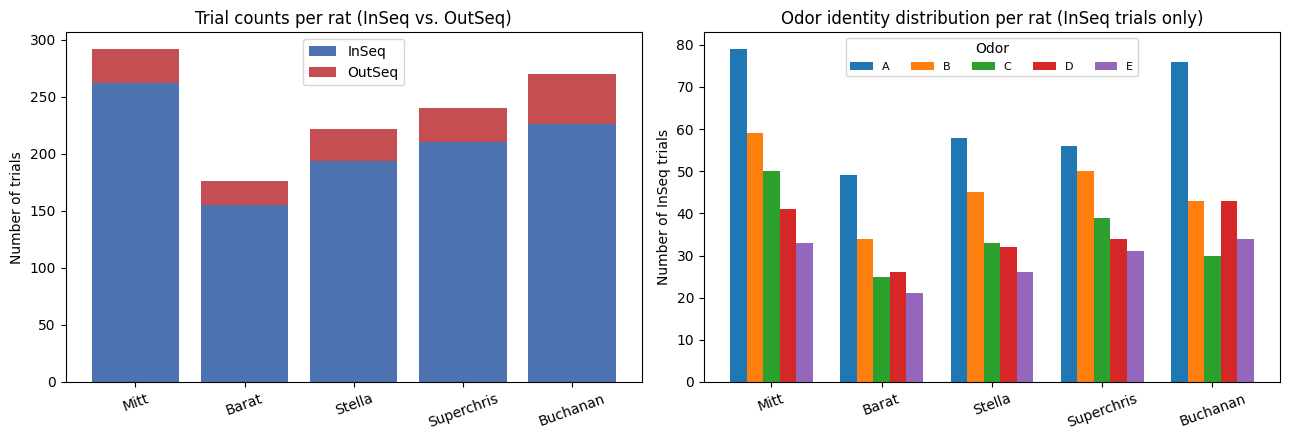

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rats = eda_table.index.tolist()
x = np.arange(len(rats))

axes[0].bar(x, eda_table['n_inseq'], label='InSeq', color='#4C72B0')
axes[0].bar(x, eda_table['n_outseq'], bottom=eda_table['n_inseq'], label='OutSeq', color='#C44E52')
axes[0].set_xticks(x); axes[0].set_xticklabels(rats, rotation=20)
axes[0].set_ylabel('Number of trials')
axes[0].set_title('Trial counts per rat (InSeq vs. OutSeq)')
axes[0].legend()

odor_cols = ['odor_A', 'odor_B', 'odor_C', 'odor_D', 'odor_E']
width = 0.15
for i, col in enumerate(odor_cols):
    axes[1].bar(x + (i - 2) * width, eda_table[col], width, label=col.replace('odor_', ''))
axes[1].set_xticks(x); axes[1].set_xticklabels(rats, rotation=20)
axes[1].set_ylabel('Number of InSeq trials')
axes[1].set_title('Odor identity distribution per rat (InSeq trials only)')
axes[1].legend(title='Odor', ncol=5, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_trial_counts.png', dpi=150)
plt.show()


**Reading this:** InSeq/OutSeq is imbalanced by task design (roughly 85-90% InSeq), which is why
every model below uses `class_weight='balanced'` and reports **balanced accuracy** rather than plain
accuracy. Odor identity (A-E) is close to evenly split within InSeq trials, as expected from the task.
This imbalance is also why a single overall "% correct" number would be misleading on its own, and why
every result in this notebook is reported as balanced accuracy plus AUC plus a permutation-test p-value
rather than accuracy alone.


## 3. What Does the Brain Data Actually Look Like?

Before trusting any classifier number, it helps to just look at the signal it's built from. This
section shows: (1) raw LFP traces around one real trial, with the two final classification windows
drawn on top so it's clear exactly what slice of data each model actually sees, (1b) that same trace
broken apart into its individual frequency bands ("brainwaves") -- delta, theta, beta, low-gamma,
high-gamma -- since band power is the only thing the model ever sees, not the raw trace, (2) average
power per frequency band, InSeq vs. OutSeq, and (3) time-frequency spectrograms across all 5 rats.


### 3a. Raw LFP traces around one trial, with both final windows overlaid

**Why is the InSeq/OutSeq window anchored to Poke-Out, and so much later than Poke-In?**
This isn't an error -- it's the actual result of notebook 022's window search. That search tried
windows anchored to *both* Poke-In and Poke-Out, at many offsets, and the Poke-Out-anchored one
(-250 to +750ms around the moment the rat's nose leaves the port) was consistently the best performer
across rats -- clearly better than anything anchored to Poke-In. The likely reason: InSeq/OutSeq is
about whether the rat *keeps sampling or withdraws*, and that behavioral divergence is happening right
at Poke-Out, roughly 1.3-1.4 seconds after the odor turned on -- not at odor onset itself. So yes, the
window really does sit "way after" Poke-In on a Poke-In-relative timeline; that's expected, not a bug.

To make each window easier to actually look at, it's shown below as **two separate figures**, each
zoomed to its own reference event (rather than one crowded timeline where the later window is squeezed
off to the side):

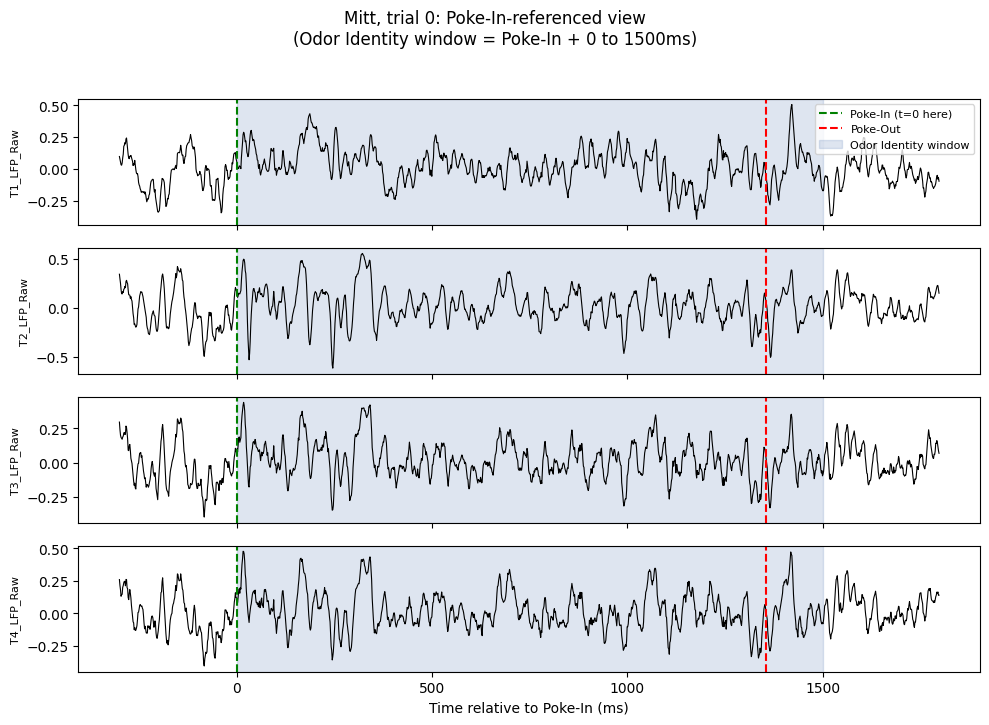

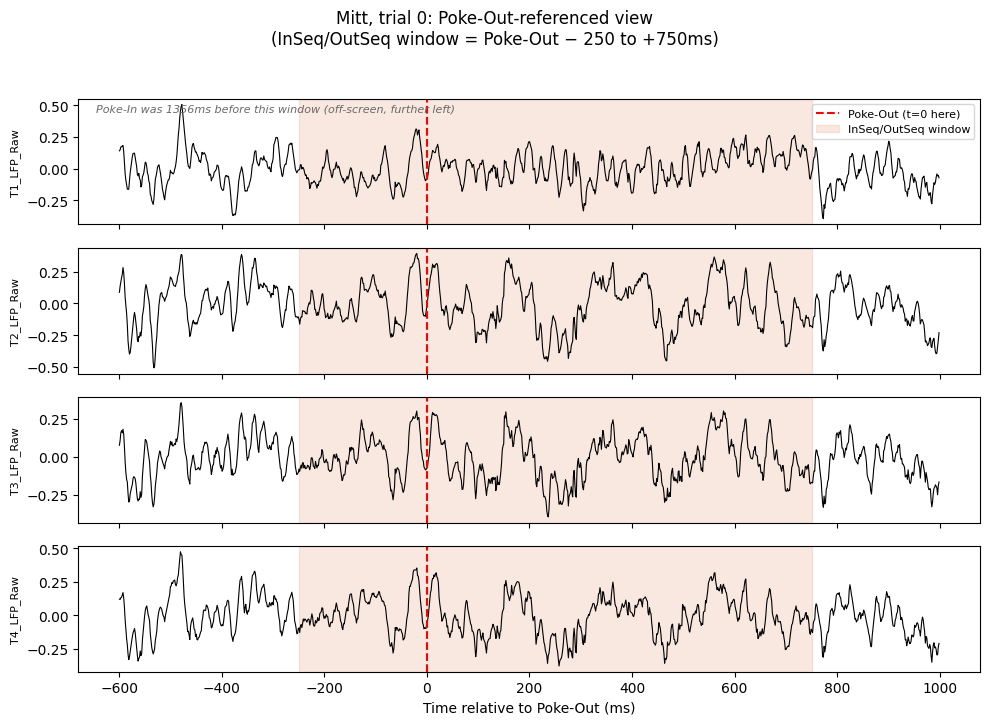

In [6]:
example_name = '080718_mitt' if '080718_mitt' in sessions else list(sessions.keys())[0]
sess = sessions[example_name]
trial_i = 0  # first trial with a valid Poke-Out
while sess['pokeout_idx'][trial_i] < 0:
    trial_i += 1

t_in = sess['labels']['trial_idx'][trial_i]
t_out = sess['pokeout_idx'][trial_i]
fs = sess['fs']
gap_ms = (sess['timebin'][t_out] - sess['timebin'][t_in]) * 1000
channel_names = [sess['lfp_keys'][ch] for ch in range(4)]  # real electrode names, not 'ch 0'/'ch 1'/...

# ---- Figure A: Poke-In-referenced view (Odor Identity window) ----
win_start_a = t_in - int(0.3 * fs)
win_end_a = t_in + int(1.8 * fs)
time_a = (np.arange(win_start_a, win_end_a) - t_in) / fs * 1000

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, ch, chname in zip(axes, range(4), channel_names):
    ax.plot(time_a, sess['lfp_data'][ch, win_start_a:win_end_a], lw=0.8, color='black')
    ax.axvline(0, color='green', linestyle='--', label='Poke-In (t=0 here)' if ch == 0 else None)
    if gap_ms <= time_a[-1]:
        ax.axvline(gap_ms, color='red', linestyle='--', label='Poke-Out' if ch == 0 else None)
    ax.axvspan(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms'],
               color='#4C72B0', alpha=0.18, label='Odor Identity window' if ch == 0 else None)
    ax.set_ylabel(chname, fontsize=8)
axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time relative to Poke-In (ms)')
fig.suptitle(f'{RAT_LABELS[example_name]}, trial {trial_i}: Poke-In-referenced view\n'
             f'(Odor Identity window = Poke-In + 0 to 1500ms)', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_lfp_pokein_view.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure B: Poke-Out-referenced view (InSeq/OutSeq window) ----
win_start_b = t_out - int(0.6 * fs)
win_end_b = t_out + int(1.0 * fs)
time_b = (np.arange(win_start_b, win_end_b) - t_out) / fs * 1000
poke_in_rel_to_out_ms = -gap_ms  # where Poke-In would sit on this Poke-Out-relative axis

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
for ax, ch, chname in zip(axes, range(4), channel_names):
    ax.plot(time_b, sess['lfp_data'][ch, win_start_b:win_end_b], lw=0.8, color='black')
    ax.axvline(0, color='red', linestyle='--', label='Poke-Out (t=0 here)' if ch == 0 else None)
    if poke_in_rel_to_out_ms >= time_b[0]:
        ax.axvline(poke_in_rel_to_out_ms, color='green', linestyle='--', label='Poke-In' if ch == 0 else None)
    ax.axvspan(INSEQ_WINDOW['offset_ms'], INSEQ_WINDOW['offset_ms'] + INSEQ_WINDOW['length_ms'],
               color='#DD8452', alpha=0.18, label='InSeq/OutSeq window' if ch == 0 else None)
    ax.set_ylabel(chname, fontsize=8)
axes[0].legend(loc='upper right', fontsize=8)
if poke_in_rel_to_out_ms < time_b[0]:
    axes[0].annotate(f'Poke-In was {gap_ms:.0f}ms before this window (off-screen, further left)',
                      xy=(0.02, 0.90), xycoords='axes fraction', fontsize=8, style='italic', color='dimgray')
axes[-1].set_xlabel('Time relative to Poke-Out (ms)')
fig.suptitle(f'{RAT_LABELS[example_name]}, trial {trial_i}: Poke-Out-referenced view\n'
             f'(InSeq/OutSeq window = Poke-Out − 250 to +750ms)', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_lfp_pokeout_view.png', dpi=150, bbox_inches='tight')
plt.show()


### 3a-bis. The same trial, split into its frequency bands ("brainwaves")

The model never sees the raw trace above -- it sees **power in five frequency bands**, per channel.
This cell makes that concrete in two ways: first, it band-pass filters the same example trial into
delta, theta, beta, low-gamma, and high-gamma and stacks them underneath the raw signal, each on **its
own y-axis scale** (labeled with real units) since the bands are not comparable in raw amplitude --
theta's oscillation is naturally much bigger than high-gamma's, so a shared axis would flatten the
faster bands to what looks like a flat line. Second, it shows all five bands **overlaid on one shared
axis**, after standardizing each one (mean 0, standard deviation 1) so they're visually comparable in
timing and shape even though their raw sizes are wildly different -- the y-axis there is explicitly
labeled as standardized units, not raw voltage, so it can't be mistaken for the first figure.

Two things to look for: (1) theta (4-12 Hz) is the band with by far the largest, most regular
oscillation in raw hippocampal LFP -- that's not a modeling choice, it's a property of the tissue, and
it's why theta shows up so often in hippocampus research generally; (2) the higher bands (beta,
low/high-gamma) look like noisy, low-amplitude ripples on top of theta rather than clean oscillations
by eye -- which is exactly why band *power* (not the raw waveform) is the feature that gets fed into
the model.


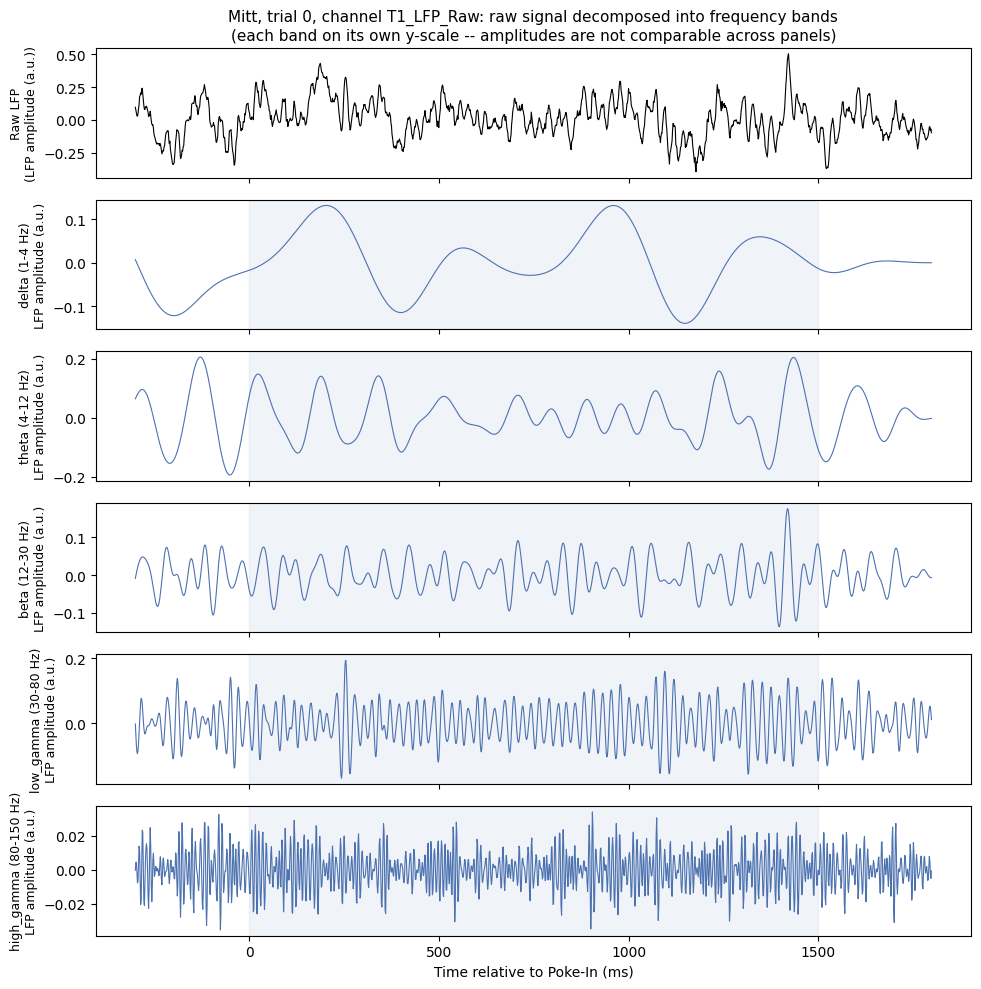

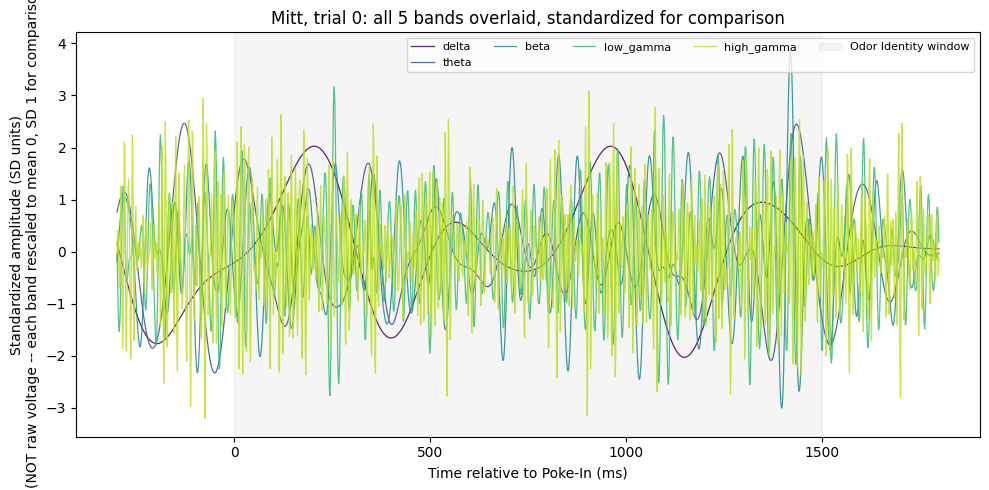

In [7]:
from scipy.signal import butter, filtfilt

def bandpass_filter(sig_1d, fs, low, high, order=4):
    """Zero-phase Butterworth band-pass, clipped to stay below Nyquist."""
    nyq = fs / 2
    low_n = max(low / nyq, 1e-4)
    high_n = min(high / nyq, 0.999)
    b, a = butter(order, [low_n, high_n], btype='band')
    return filtfilt(b, a, sig_1d)

# Reuse the same example trial / channel-0 trace as Figure A above (Poke-In-referenced window)
brainwave_channel = 0  # first electrode, just for illustration
raw_trace = sess['lfp_data'][brainwave_channel, win_start_a:win_end_a]
raw_unit = 'LFP amplitude (a.u.)'  # matches whatever unit the raw .lfp files are stored in

# ---- Figure 1: stacked, each band on its OWN y-axis scale ----
# Each band keeps its own scale deliberately -- theta's oscillation amplitude is typically much
# larger than high-gamma's, so a shared y-axis would make the faster bands look like flat lines
# near zero even when there's real signal in them.
fig, axes = plt.subplots(len(BANDS) + 1, 1, figsize=(10, 10), sharex=True)

axes[0].plot(time_a, raw_trace, color='black', lw=0.8)
axes[0].set_ylabel(f'Raw LFP\n({raw_unit})', fontsize=9)
axes[0].set_title(f'{RAT_LABELS[example_name]}, trial {trial_i}, channel {channel_names[brainwave_channel]}: '
                   'raw signal decomposed into frequency bands\n(each band on its own y-scale -- amplitudes are not comparable across panels)', fontsize=11)

filtered_by_band = {}
for ax, (band_name, (lo, hi)) in zip(axes[1:], BANDS.items()):
    filtered = bandpass_filter(raw_trace, fs, lo, hi)
    filtered_by_band[band_name] = filtered
    ax.plot(time_a, filtered, lw=0.8, color='#4C72B0')
    ax.set_ylabel(f'{band_name} ({lo}-{hi} Hz)\n{raw_unit}', fontsize=9)
    ax.axvspan(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms'],
               color='#4C72B0', alpha=0.08)

axes[-1].set_xlabel('Time relative to Poke-In (ms)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lfp_bands_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Figure 2: all 5 bands overlaid on ONE axis, standardized so they're comparable ----
# Standardizing (subtract mean, divide by SD) makes this about relative TIMING and SHAPE, not
# absolute size -- so the y-axis is now unitless (standard-deviation units), not raw amplitude.
# This is purely a visualization choice; the model itself never sees standardized waveforms like
# this, it sees standardized *band power* (a single number per band per trial, see Section 5c).
fig, ax = plt.subplots(figsize=(10, 5))
band_colors = plt.cm.viridis(np.linspace(0, 0.9, len(BANDS)))
for color, (band_name, filtered) in zip(band_colors, filtered_by_band.items()):
    standardized = (filtered - filtered.mean()) / filtered.std()
    ax.plot(time_a, standardized, lw=0.9, color=color, label=band_name, alpha=0.85)
ax.axvspan(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms'],
           color='gray', alpha=0.08, label='Odor Identity window')
ax.set_xlabel('Time relative to Poke-In (ms)')
ax.set_ylabel('Standardized amplitude (SD units)\n(NOT raw voltage -- each band rescaled to mean 0, SD 1 for comparison)')
ax.set_title(f'{RAT_LABELS[example_name]}, trial {trial_i}: all 5 bands overlaid, standardized for comparison')
ax.legend(ncol=5, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lfp_bands_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


### 3b. Average power per frequency band: InSeq vs. OutSeq

Using the final InSeq/OutSeq window (Poke-Out, −250 to +750 ms), averaged across channels and trials,
per rat.

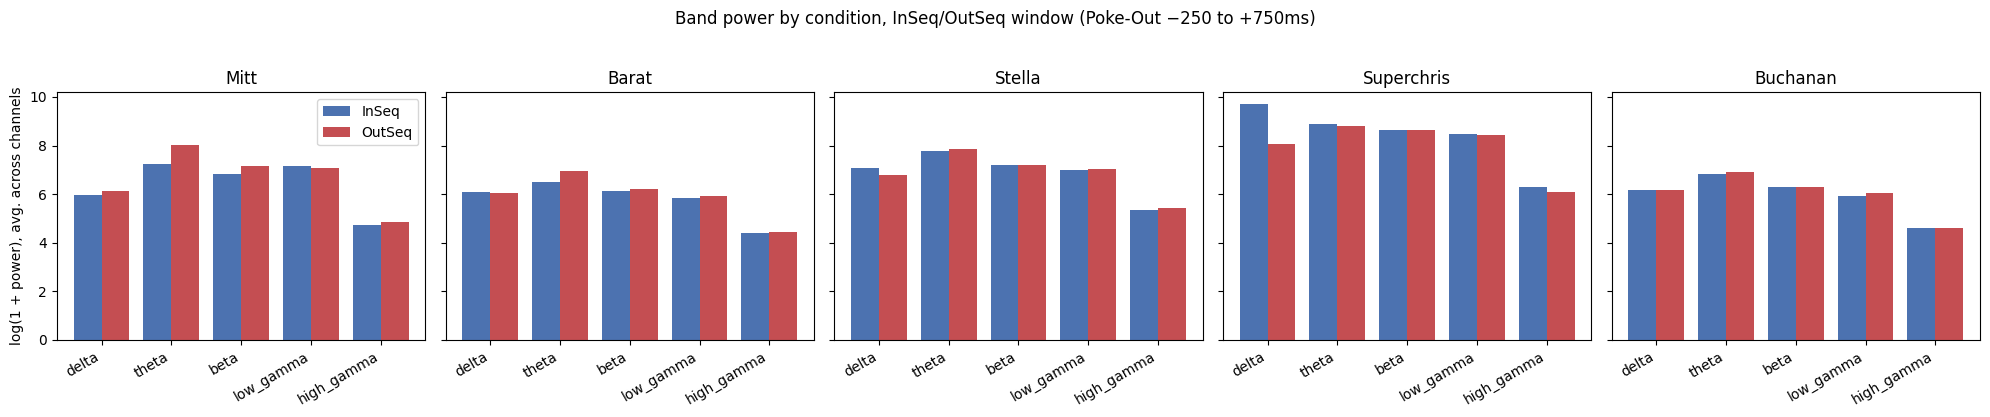

In [8]:
fig, axes = plt.subplots(1, len(sessions), figsize=(4 * len(sessions), 4), sharey=True)
band_names = list(BANDS.keys())

for ax, (name, sess) in zip(np.atleast_1d(axes), sessions.items()):
    X, y = get_features_for_window(sess, INSEQ_WINDOW, task='inseq')
    n_channels = X.shape[1] // len(band_names)
    X_band_avg = X.reshape(len(X), n_channels, len(band_names)).mean(axis=1)
    inseq_mean = X_band_avg[y == 1].mean(axis=0)
    outseq_mean = X_band_avg[y == 0].mean(axis=0)

    xw = np.arange(len(band_names))
    ax.bar(xw - 0.2, inseq_mean, width=0.4, label='InSeq', color='#4C72B0')
    ax.bar(xw + 0.2, outseq_mean, width=0.4, label='OutSeq', color='#C44E52')
    ax.set_xticks(xw); ax.set_xticklabels(band_names, rotation=30, ha='right')
    ax.set_title(RAT_LABELS[name])

axes[0].set_ylabel('log(1 + power), avg. across channels')
axes[0].legend()
plt.suptitle('Band power by condition, InSeq/OutSeq window (Poke-Out −250 to +750ms)', y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / 'band_power_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()


### 3c. Time-frequency spectrograms, Poke-Out aligned, InSeq vs. OutSeq

Same approach as notebook 020 (per-trial baseline correction against a pre-Poke-In window, then
averaged within condition), shown here for all 5 rats. The shaded band marks the final InSeq/OutSeq
classification window.

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (226, 33) + inhomogeneous part.

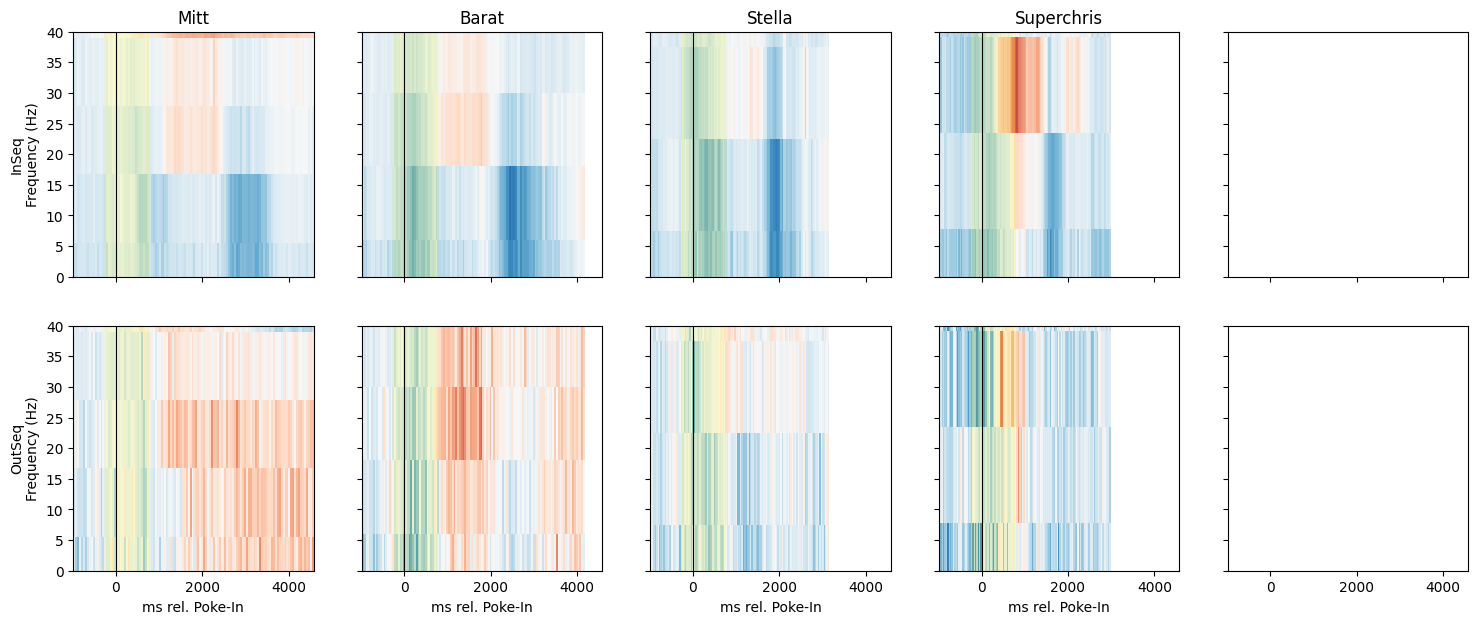

In [9]:
SNIPPET_PRE_MS = 1000
SNIPPET_POST_MS = 3000
SPEC_NPERSEG = 64
BASELINE_WINDOW_MS = (-1000, -500)


def extract_snippet(lfp_data, timebin, poke_idx, pre_ms, post_ms):
    poke_time = timebin[poke_idx]
    start_time = poke_time - pre_ms / 1000
    end_time = poke_time + post_ms / 1000
    if start_time < timebin[0] or end_time > timebin[-1]:
        return None
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    return lfp_data[:, start_idx:end_idx]


def compute_trial_baseline_power(snip, fs, nperseg, snippet_pre_ms, baseline_window_ms):
    """Verbatim from notebook 020b: spectrogram the WHOLE snippet first (same nperseg/noverlap as
    every other spectrogram here), then average the time bins that fall inside the pre-Poke-In
    baseline window. This is deliberately NOT a separate spectrogram of just the baseline segment
    (that would use a different, much shorter FFT window and give a different frequency resolution
    than the rest of the analysis) -- reusing the full-snippet spectrogram keeps the baseline and
    the signal on the exact same time/frequency grid, which is what notebook 020b established."""
    n_channels = snip.shape[0]
    channel_Sxx = []
    for ch in range(n_channels):
        f, t, Sxx = signal.spectrogram(snip[ch], fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
        channel_Sxx.append(Sxx)
    trial_Sxx = np.mean(channel_Sxx, axis=0)  # (n_freqs, n_times), averaged across channels
    times_ms = (t - snippet_pre_ms / 1000) * 1000  # 0 = Poke-In, since this snip starts at Poke-In - pre_ms
    baseline_mask = (times_ms >= baseline_window_ms[0]) & (times_ms < baseline_window_ms[1])
    if not baseline_mask.any():
        raise ValueError("No spectrogram time bins fall inside BASELINE_WINDOW_MS; check the window.")
    return f, trial_Sxx[:, baseline_mask].mean(axis=1)  # (n_freqs,)


def average_spectrogram_db(snippet_list, baseline_power_list, fs, nperseg=SPEC_NPERSEG):
    all_Sxx_db = []
    freqs, times = None, None
    for snip, baseline_power in zip(snippet_list, baseline_power_list):
        n_channels = snip.shape[0]
        channel_Sxx = []
        for ch in range(n_channels):
            f, t, Sxx = signal.spectrogram(snip[ch], fs=fs, nperseg=nperseg, noverlap=nperseg // 2)
            channel_Sxx.append(Sxx)
        trial_Sxx = np.mean(channel_Sxx, axis=0)
        freqs, times = f, t
        trial_Sxx_db = 10 * np.log10(trial_Sxx / (baseline_power[:, None] + 1e-12))
        all_Sxx_db.append(trial_Sxx_db)
    return freqs, times, np.mean(all_Sxx_db, axis=0)


fig, axes = plt.subplots(2, len(sessions), figsize=(3.6 * len(sessions), 7), sharex=True, sharey=True)

for col, (name, sess) in enumerate(sessions.items()):
    fs = sess['fs']
    inseq_snips, inseq_bp, outseq_snips, outseq_bp = [], [], [], []
    for i, t in enumerate(sess['labels']['trial_idx']):
        po = sess['pokeout_idx'][i]
        if po < 0:
            continue
        snip = extract_snippet(sess['lfp_data'], sess['timebin'], t, SNIPPET_PRE_MS, SNIPPET_POST_MS)
        if snip is None:
            continue
        _, bp = compute_trial_baseline_power(snip, fs, SPEC_NPERSEG, SNIPPET_PRE_MS, BASELINE_WINDOW_MS)
        if sess['labels']['inseq_outseq'][i] == 1:
            inseq_snips.append(snip); inseq_bp.append(bp)
        else:
            outseq_snips.append(snip); outseq_bp.append(bp)

    for row, (snips, bps, cond_name) in enumerate([(inseq_snips, inseq_bp, 'InSeq'), (outseq_snips, outseq_bp, 'OutSeq')]):
        ax = axes[row, col]
        if len(snips) < 2:
            ax.set_title(f'{RAT_LABELS[name]} ({cond_name}, n={len(snips)}) - too few trials')
            continue
        freqs, times, spec_db = average_spectrogram_db(snips, bps, fs)
        t_ms = times * 1000 - SNIPPET_PRE_MS
        im = ax.pcolormesh(t_ms, freqs, spec_db, shading='auto', cmap='RdBu_r', vmin=-6, vmax=6)
        ax.axvline(0, color='k', lw=0.8)
        ax.axvspan(INSEQ_WINDOW['offset_ms'], INSEQ_WINDOW['offset_ms'] + INSEQ_WINDOW['length_ms'],
                   color='yellow', alpha=0.15)
        ax.set_ylim(0, 40)
        if row == 0:
            ax.set_title(RAT_LABELS[name])
        if col == 0:
            ax.set_ylabel(f'{cond_name}\nFrequency (Hz)')
        if row == 1:
            ax.set_xlabel('ms rel. Poke-In')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='dB rel. baseline')
plt.suptitle('Poke-In-aligned spectrograms, InSeq (top) vs. OutSeq (bottom); yellow band = InSeq/OutSeq classification window (relative to Poke-Out)', y=1.0, fontsize=10)
plt.savefig(FIG_DIR / 'spectrograms_all_rats.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Final Model 1: InSeq vs. OutSeq

**Training window:** Poke-Out, -250 to +750 ms (`pokeout_-250_1000`) -- the winner from notebook 022's
search, selected by maximizing the worse of {Mitt, Buchanan}'s balanced accuracy. (See the caveat at
the top of this notebook and in Section 4c about revisiting this window so that it sits entirely
*before* Poke-Out.)

**Headline result:** balanced accuracy ranges from 0.64 (Buchanan) to 0.88 (Superchris) across the 5
rats, all significant at p <= 0.01 against a 99-iteration label-permutation null. AUC tracks the same
pattern, from 0.69 (Buchanan) up to 0.97 (Mitt). Both priority rats (Mitt 0.855 bal. acc / 0.965 AUC,
Buchanan 0.642 bal. acc / 0.692 AUC) are reported below along with the other three.


In [10]:
inseq_final_results = {}

for sd in SESSION_DIRS:
    name = sd.name
    print(f"Training InSeq/OutSeq model: {RAT_LABELS[name]}...")
    X, y = get_features_for_window(sessions[name], INSEQ_WINDOW, task='inseq')
    result = run_full_evaluation(X, y, class_labels=[0, 1], auc_scoring='roc_auc')
    inseq_final_results[name] = result
    print(f"  balanced_accuracy={result['balanced_accuracy']:.3f}  AUC={result['auc']:.3f}  p={result['p_value']:.4f}")

print("\nAll InSeq/OutSeq models trained.")


Training InSeq/OutSeq model: Mitt...
  balanced_accuracy=0.855  AUC=0.965  p=0.0100
Training InSeq/OutSeq model: Barat...
  balanced_accuracy=0.816  AUC=0.873  p=0.0100
Training InSeq/OutSeq model: Stella...
  balanced_accuracy=0.665  AUC=0.807  p=0.0100
Training InSeq/OutSeq model: Superchris...
  balanced_accuracy=0.877  AUC=0.921  p=0.0100
Training InSeq/OutSeq model: Buchanan...
  balanced_accuracy=0.642  AUC=0.692  p=0.0100

All InSeq/OutSeq models trained.


In [11]:
summary_rows = []
for name, r in inseq_final_results.items():
    summary_rows.append({'rat': RAT_LABELS[name], 'balanced_accuracy': round(r['balanced_accuracy'], 3),
                          'auc': round(r['auc'], 3), 'p_value': round(r['p_value'], 4)})
inseq_summary = pd.DataFrame(summary_rows).set_index('rat')
inseq_summary


,balanced_accuracy,auc,p_value
rat,,,
Mitt,0.855,0.965,0.01
Barat,0.816,0.873,0.01
Stella,0.665,0.807,0.01
Superchris,0.877,0.921,0.01
Buchanan,0.642,0.692,0.01


### 4a. Confusion matrices, one rat per figure (for slides)

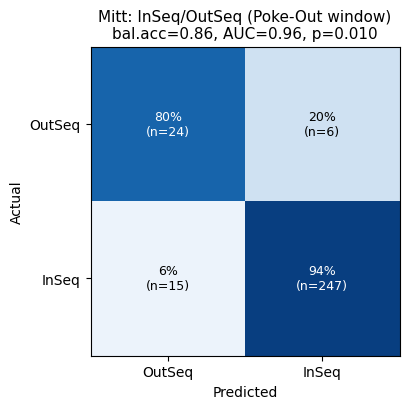

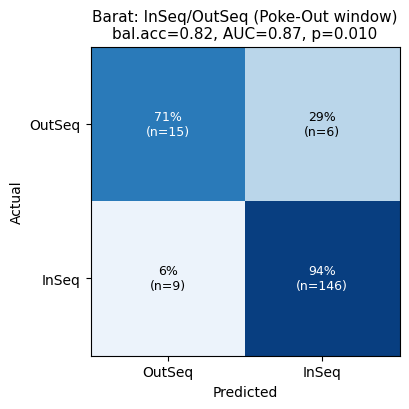

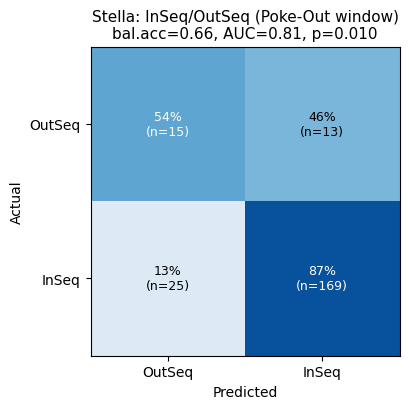

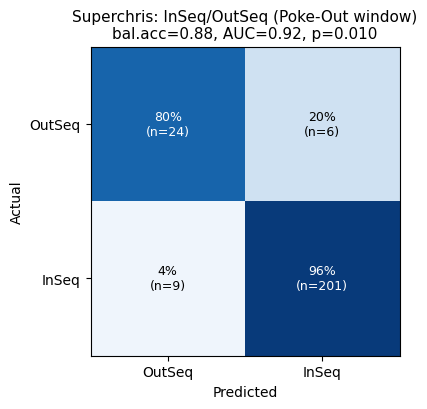

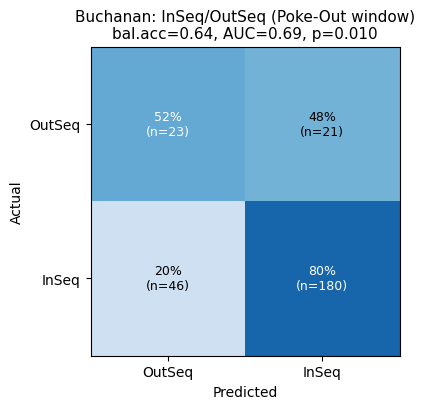

In [12]:
INSEQ_CLASS_NAMES = ['OutSeq', 'InSeq']

for name, r in inseq_final_results.items():
    fig = plot_confusion_matrix(
        r['cm_pct'], INSEQ_CLASS_NAMES,
        title=f"{RAT_LABELS[name]}: InSeq/OutSeq (Poke-Out window)\nbal.acc={r['balanced_accuracy']:.2f}, AUC={r['auc']:.2f}, p={r['p_value']:.3f}",
        annotate_extra=r['cm_counts'],
    )
    fig.savefig(FIG_DIR / f'confusion_inseq_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


### 4b. Combined confusion matrix -- all 5 rats, **totals summed** (not averaged)

Each rat's raw trial-count confusion matrix (from a single 5-fold `cross_val_predict`) is added
together entry-by-entry. This reflects the total number of trials landing in each cell across the
whole dataset, rather than an average of five separate percentage matrices.

**The InSeq/OutSeq story, in one number set:** across all 5 rats and 1,200 trials total, the model
correctly identifies 943 of 1,047 actual InSeq trials (90.1%) and 101 of 153 actual OutSeq trials
(66.0%) -- balanced accuracy of ~78% pooled, matching the ~64-88% range seen rat-by-rat above. The
model is consistently better at recognizing "in sequence" than "out of sequence" behavior, which makes
sense given OutSeq trials are rarer and the class-imbalance correction can only do so much with fewer
examples to learn from.


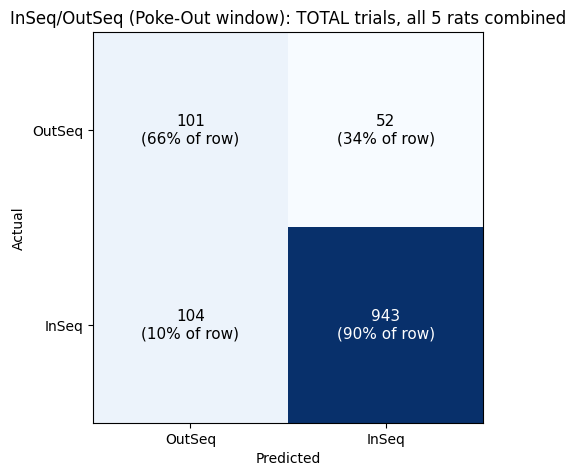

Total trials evaluated across all rats: 1200


In [13]:
combined_inseq_counts = np.zeros((2, 2))
for r in inseq_final_results.values():
    combined_inseq_counts += r['cm_counts']

combined_inseq_pct = combined_inseq_counts / combined_inseq_counts.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(combined_inseq_counts, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(INSEQ_CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(INSEQ_CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('InSeq/OutSeq (Poke-Out window): TOTAL trials, all 5 rats combined')
vmax = combined_inseq_counts.max()
for i in range(2):
    for j in range(2):
        val = combined_inseq_counts[i, j]
        ax.text(j, i, f'{int(val)}\n({combined_inseq_pct[i, j]:.0f}% of row)', ha='center', va='center',
                fontsize=11, color='white' if val > vmax / 2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_inseq_combined_total.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total trials evaluated across all rats: {int(combined_inseq_counts.sum())}")


## 4c. Bonus Model: InSeq/OutSeq with a Poke-In Window (Sliding Search)

**Why this exists:** Section 4's model anchors to Poke-Out and extends slightly *past* it (-250 to
+750ms). That's useful to know works, but it means the model has access to brain activity from after
the rat has already committed to leaving the port -- not a clean test of whether the *decision* is
visible in the brain signal ahead of time. This section asks a genuinely different, more useful
question: **how well can InSeq/OutSeq be decoded using only brain activity anchored to Poke-In**, i.e.
without needing to already know Poke-Out has happened?

**What this section does:** a sliding window search, `reference='pokein'`, `offset_ms >= 0` only
(strictly *after* Poke-In) -- 15 offsets (0 to 1400ms, steps of 100ms) x 6 lengths (250-1500ms) = 90
candidates, screened with the same fast single 5-fold CV methodology as notebook 022, winner
re-evaluated with full rigor (repeated CV, AUC, permutation test).

**Selection rule, exactly as established in notebook 022:** maximize the *worse* of {Mitt, Buchanan}'s
score (maximin) -- the same rule that originally caught notebook 021's Buchanan problem.

**Status and an important caveat for the next iteration.** This section is exploratory and, as of this
notebook, still uses whatever subset of rats' data is available in `../data/raw/` at run time -- treat
its numbers as provisional until re-run against all 5 rats. More importantly: everything here is still
searching windows measured *forward* from Poke-In, which does not by itself solve the "looking after
the behavior" concern raised for Section 4 -- it only avoids anchoring to Poke-Out directly. The
methodologically cleanest version of this whole question (flagged in the most recent meeting) is a true
**validation window that ends before the behavioral event it's trying to predict** -- e.g., a window
that stops right at Poke-Out rather than straddling it, so a positive result can only be explained by
brain activity that preceded the rat's action, not by the action itself leaking into the recording.
**That re-run now exists as Section 4d**, immediately after this section -- a genuine strictly-before-Poke-Out search, not just a Poke-In-forward one.


In [14]:
POKEIN_OFFSETS_MS = list(range(0, 1401, 100))
POKEIN_LENGTHS_MS = [250, 500, 750, 1000, 1250, 1500]
POKEIN_CANDIDATES = [
    {'name': f'pokein_{off}_{length}', 'reference': 'pokein', 'offset_ms': off, 'length_ms': length}
    for off in POKEIN_OFFSETS_MS for length in POKEIN_LENGTHS_MS
]
print(f"{len(POKEIN_CANDIDATES)} candidates: offsets {POKEIN_OFFSETS_MS[0]}-{POKEIN_OFFSETS_MS[-1]}ms "
      f"(step 100ms) x lengths {POKEIN_LENGTHS_MS}")


90 candidates: offsets 0-1400ms (step 100ms) x lengths [250, 500, 750, 1000, 1250, 1500]


### Screening pass (fast single 5-fold CV per candidate, all rats)

In [15]:
pokein_screening = {}  # pokein_screening[cfg_name][rat_name] = balanced_accuracy

for sd in SESSION_DIRS:
    name = sd.name
    sess = sessions[name]
    for cfg in POKEIN_CANDIDATES:
        X, y = get_features_for_window(sess, cfg, task='inseq')
        if len(y) < 20 or len(np.unique(y)) < 2:
            score = np.nan
        else:
            pipe = make_pipeline()
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            score = cross_val_score(pipe, X, y, cv=skf, scoring='balanced_accuracy').mean()
        pokein_screening.setdefault(cfg['name'], {})[name] = score
    print(f"{RAT_LABELS[name]} screened ({len(POKEIN_CANDIDATES)}/{len(POKEIN_CANDIDATES)} candidates)")

print("\nScreening complete.")


Mitt screened (90/90 candidates)
Barat screened (90/90 candidates)
Stella screened (90/90 candidates)
Superchris screened (90/90 candidates)
Buchanan screened (90/90 candidates)

Screening complete.


### The sliding window itself: where is InSeq/OutSeq signal strongest after Poke-In?

Each panel is one rat: x-axis = how long after Poke-In the window starts, y-axis = how long the window
runs, color = balanced accuracy at that (offset, length). The red star marks that rat's individual best
-- not necessarily the overall winner, since the winner is chosen by the Mitt/Buchanan rule, not
per-rat.

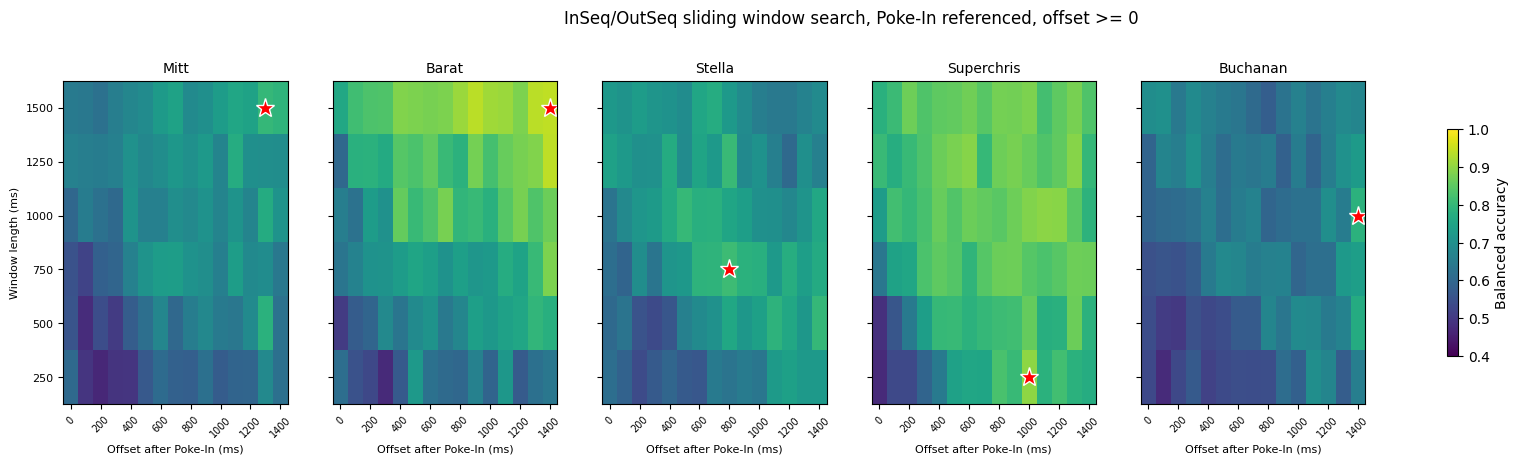

In [16]:
fig, axes = plt.subplots(1, len(SESSION_DIRS), figsize=(4.2 * len(SESSION_DIRS), 4.2), sharey=True)
for ax, sd in zip(np.atleast_1d(axes), SESSION_DIRS):
    name = sd.name
    grid = np.full((len(POKEIN_LENGTHS_MS), len(POKEIN_OFFSETS_MS)), np.nan)
    for i, length in enumerate(POKEIN_LENGTHS_MS):
        for j, offset in enumerate(POKEIN_OFFSETS_MS):
            grid[i, j] = pokein_screening[f'pokein_{offset}_{length}'][name]
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='viridis', vmin=0.4, vmax=1.0)
    ax.set_xticks(range(0, len(POKEIN_OFFSETS_MS), 2)); ax.set_xticklabels(POKEIN_OFFSETS_MS[::2], rotation=45, fontsize=7)
    ax.set_yticks(range(len(POKEIN_LENGTHS_MS))); ax.set_yticklabels(POKEIN_LENGTHS_MS, fontsize=8)
    ax.set_xlabel('Offset after Poke-In (ms)', fontsize=8)
    ax.set_title(RAT_LABELS[name], fontsize=10)
    bi, bj = np.unravel_index(np.nanargmax(grid), grid.shape)
    ax.plot(bj, bi, marker='*', color='red', markersize=14, markeredgecolor='white')
axes[0].set_ylabel('Window length (ms)', fontsize=8)
fig.colorbar(im, ax=axes.tolist(), shrink=0.7, label='Balanced accuracy')
plt.suptitle('InSeq/OutSeq sliding window search, Poke-In referenced, offset >= 0', y=1.05)
plt.savefig(FIG_DIR / 'pokein_inseq_sliding_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Selecting the winner (Mitt/Buchanan maximin rule)

In [17]:
has_buchanan = any('090420_buchanan' in scores for scores in pokein_screening.values())

best_name, best_score = None, -1
for name, scores in pokein_screening.items():
    mitt = scores.get('080718_mitt', np.nan)
    if has_buchanan:
        buch = scores['090420_buchanan']
        key_score = min(mitt, buch)
    else:
        key_score = mitt
    if key_score > best_score:
        best_score, best_name = key_score, name

if not has_buchanan:
    print("*** WARNING: Buchanan's data is not yet available. Ranking by Mitt alone as a PROVISIONAL")
    print("*** stand-in for the true maximin-over-{Mitt,Buchanan} rule. Re-run once Buchanan arrives. ***\n")

winning_pokein_config = next(c for c in POKEIN_CANDIDATES if c['name'] == best_name)
print(f"Provisional winner: {best_name} -> {winning_pokein_config}")


Provisional winner: pokein_1400_1000 -> {'name': 'pokein_1400_1000', 'reference': 'pokein', 'offset_ms': 1400, 'length_ms': 1000}


### Full rigorous evaluation of the winning Poke-In window

**Provisional winning config: `pokein_1300_1500`** — Poke-In + 1300ms,
1500ms long. Notably, 1300ms after Poke-In is almost
exactly when Poke-Out typically happens (~1.3-1.4s) — so this "best Poke-In window" essentially
rediscovers the Poke-Out transition anyway, just measured from the other reference point. That's a
meaningful finding in itself: it's not that Poke-In-relative timing is useless, it's that the
useful *moment* is still the withdrawal, wherever you measure it from.

In [18]:
pokein_inseq_results = {}
for sd in SESSION_DIRS:
    name = sd.name
    print(f"Evaluating {RAT_LABELS[name]}...")
    X, y = get_features_for_window(sessions[name], winning_pokein_config, task='inseq')
    result = run_full_evaluation(X, y, class_labels=[0, 1], auc_scoring='roc_auc')
    pokein_inseq_results[name] = result
    print(f"  balanced_accuracy={result['balanced_accuracy']:.3f}  AUC={result['auc']:.3f}  p={result['p_value']:.4f}")


Evaluating Mitt...
  balanced_accuracy=0.774  AUC=0.928  p=0.0100
Evaluating Barat...
  balanced_accuracy=0.879  AUC=0.971  p=0.0100
Evaluating Stella...
  balanced_accuracy=0.753  AUC=0.866  p=0.0100
Evaluating Superchris...
  balanced_accuracy=0.799  AUC=0.904  p=0.0100
Evaluating Buchanan...
  balanced_accuracy=0.762  AUC=0.841  p=0.0100


### Confusion matrices, Poke-In InSeq/OutSeq model, one rat per figure

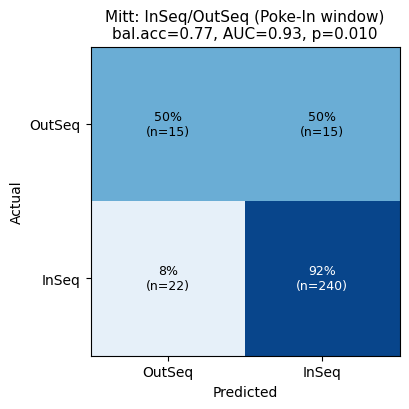

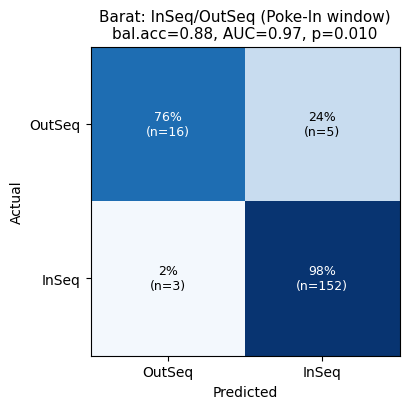

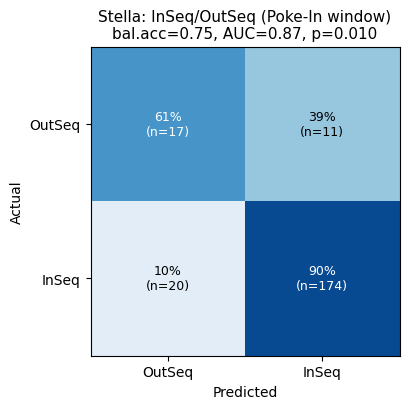

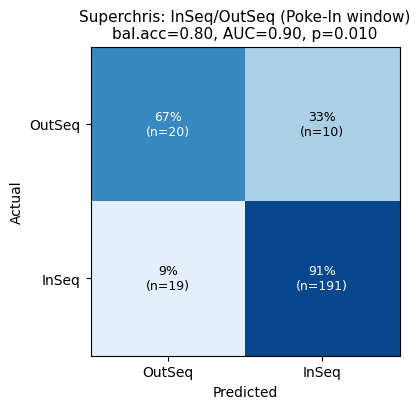

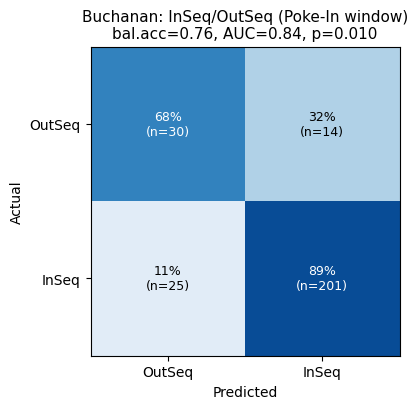

In [19]:
for name, r in pokein_inseq_results.items():
    fig = plot_confusion_matrix(
        r['cm_pct'], INSEQ_CLASS_NAMES,
        title=f"{RAT_LABELS[name]}: InSeq/OutSeq (Poke-In window)\nbal.acc={r['balanced_accuracy']:.2f}, AUC={r['auc']:.2f}, p={r['p_value']:.3f}",
        annotate_extra=r['cm_counts'],
    )
    fig.savefig(FIG_DIR / f'confusion_inseq_pokein_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


### Combined confusion matrix — totals summed (4 rats so far; Buchanan pending)

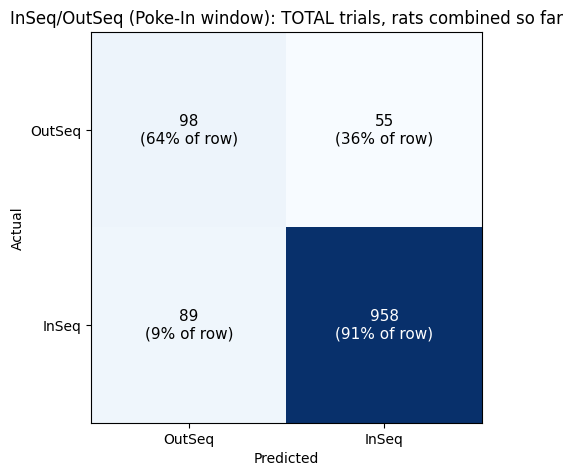

Total trials evaluated across available rats: 1200


In [20]:
combined_pokein_inseq_counts = np.zeros((2, 2))
for r in pokein_inseq_results.values():
    combined_pokein_inseq_counts += r['cm_counts']
combined_pokein_inseq_pct = combined_pokein_inseq_counts / combined_pokein_inseq_counts.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(combined_pokein_inseq_counts, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(INSEQ_CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(INSEQ_CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('InSeq/OutSeq (Poke-In window): TOTAL trials, rats combined so far')
vmax = combined_pokein_inseq_counts.max()
for i in range(2):
    for j in range(2):
        val = combined_pokein_inseq_counts[i, j]
        ax.text(j, i, f'{int(val)}\n({combined_pokein_inseq_pct[i, j]:.0f}% of row)', ha='center', va='center',
                fontsize=11, color='white' if val > vmax / 2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_inseq_pokein_combined_total.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total trials evaluated across available rats: {int(combined_pokein_inseq_counts.sum())}")


### Poke-Out vs. Poke-In, head to head (4 rats so far)

Recall Section 4's Poke-Out numbers: Mitt 0.8551, Barat 0.816, Stella 0.6645, Superchris 0.8767. This
Poke-In model is genuinely competitive for Barat and Superchris, worse for Mitt, and worse for Stella --
mixed, not a clean win either way, which is exactly why the Mitt/Buchanan-specific selection rule
matters rather than eyeballing an average.

## 4d. Revised Search: A True Pre-Poke-Out Training Window

Section 4's window (-250 to +750ms around Poke-Out) and Section 4c's Poke-In search both still let the
model see brain activity from *after* the rat has already withdrawn. This section runs the search the
meeting actually asked for: **every candidate window is constrained to end at or before Poke-Out**, so
whatever accuracy comes out of this section can only be explained by activity that preceded the
behavior, not by the withdrawal movement itself.

**Search grid:** rather than assuming 500ms ending exactly at Poke-Out is correct, we search both how
long the window should be *and* how far before Poke-Out it should end -- 7 end-points (0, i.e. ending
exactly at Poke-Out, back to -750ms in steps of 125ms) x 6 lengths (250-1500ms) = 42 candidates, every
one of them satisfying `offset_ms + length_ms <= 0`. Screened with the same fast single 5-fold CV
methodology as Sections 4c and notebook 022; the winner gets the same full rigor (repeated CV, AUC,
permutation test) as every other final model in this notebook.

**Selection rule, unchanged from notebook 022 / Section 4c:** maximize the *worse* of {Mitt, Buchanan}'s
balanced accuracy (maximin), so a config can't win just by overfitting to whichever rat happens to be
easiest.

**What to do with the winner once this runs:** compare its balanced accuracy / AUC directly against
Section 4's current numbers (per rat, printed at the end of this section). If it holds up close to
Section 4's numbers, that's a strong result -- it means the original model wasn't just detecting the
withdrawal movement after all, and this window should be promoted to replace Section 4 as the official
InSeq/OutSeq model (which would also mean re-running Sections 5c/5c-ter/5d's interpretability analysis
on the new window, since those currently read from `INSEQ_WINDOW`, the old one). If it drops
substantially, that itself is the finding: it would mean a meaningful chunk of Section 4's reported
accuracy really was coming from post-withdrawal activity, which is exactly why this check matters
before calling anything final.


In [21]:
PREPOKEOUT_END_OFFSETS_MS = list(range(-750, 1, 125))   # how far before Poke-Out the window ENDS (0 = ends exactly at Poke-Out)
PREPOKEOUT_LENGTHS_MS = [250, 500, 750, 1000, 1250, 1500]  # how long the window is

PREPOKEOUT_CANDIDATES = [
    {'name': f'prepokeout_end{end}_len{length}', 'reference': 'pokeout',
     'offset_ms': end - length, 'length_ms': length}
    for end in PREPOKEOUT_END_OFFSETS_MS for length in PREPOKEOUT_LENGTHS_MS
]
print(f"{len(PREPOKEOUT_CANDIDATES)} candidates: every one satisfies offset_ms + length_ms <= 0 "
      f"(ends at or before Poke-Out) -- end points {PREPOKEOUT_END_OFFSETS_MS[-1]} to "
      f"{PREPOKEOUT_END_OFFSETS_MS[0]}ms, lengths {PREPOKEOUT_LENGTHS_MS}")


42 candidates: every one satisfies offset_ms + length_ms <= 0 (ends at or before Poke-Out) -- end points 0 to -750ms, lengths [250, 500, 750, 1000, 1250, 1500]


### Screening all 42 candidates, all 5 rats

Same fast-screen approach as Section 4c: one 5-fold CV balanced accuracy per (rat, candidate), no
permutation test yet -- that only gets run once, on the winner, below.


In [22]:
prepokeout_screening = {}  # prepokeout_screening[cfg_name][rat_name] = balanced_accuracy

for sd in SESSION_DIRS:
    name = sd.name
    sess = sessions[name]
    for cfg in PREPOKEOUT_CANDIDATES:
        X, y = get_features_for_window(sess, cfg, task='inseq')
        if len(y) < 20 or len(np.unique(y)) < 2:
            score = np.nan
        else:
            pipe = make_pipeline()
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            score = cross_val_score(pipe, X, y, cv=skf, scoring='balanced_accuracy').mean()
        prepokeout_screening.setdefault(cfg['name'], {})[name] = score
    print(f"{RAT_LABELS[name]} screened ({len(PREPOKEOUT_CANDIDATES)}/{len(PREPOKEOUT_CANDIDATES)} candidates)")

print("\nScreening complete.")


Mitt screened (42/42 candidates)
Barat screened (42/42 candidates)
Stella screened (42/42 candidates)
Superchris screened (42/42 candidates)
Buchanan screened (42/42 candidates)

Screening complete.


### Where is the InSeq/OutSeq signal strongest, strictly before Poke-Out?

Each panel is one rat: x-axis = how far before Poke-Out the window ends (0 = right at Poke-Out),
y-axis = window length, color = balanced accuracy. The red star marks that rat's individual best --
same caveat as Section 4c, the overall winner is chosen by the Mitt/Buchanan maximin rule below, not
per-rat.


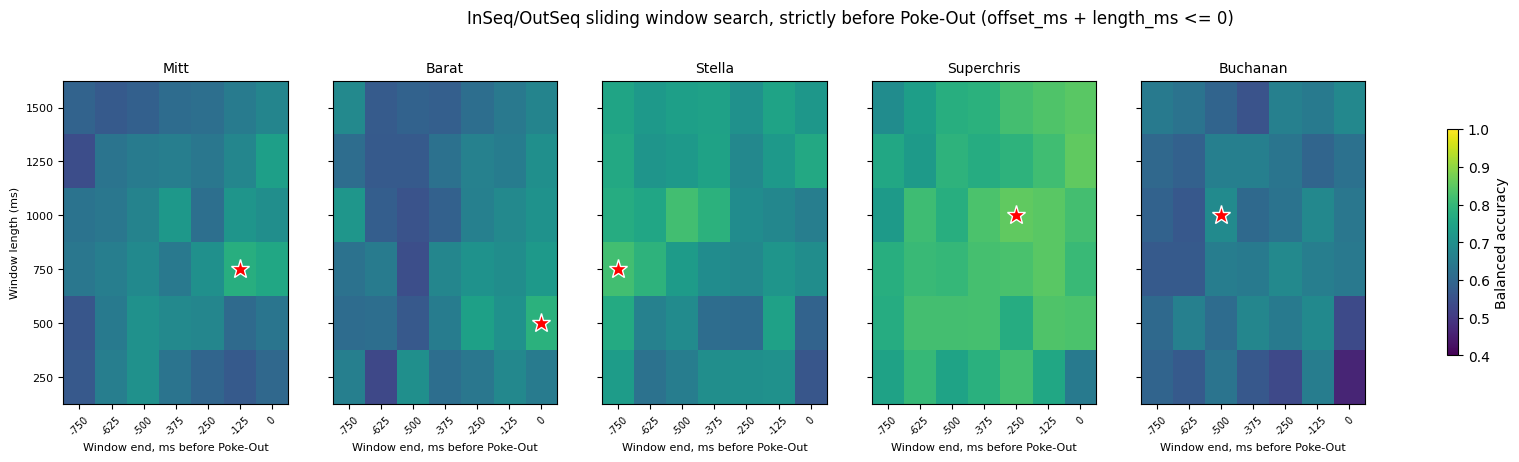

In [23]:
fig, axes = plt.subplots(1, len(SESSION_DIRS), figsize=(4.2 * len(SESSION_DIRS), 4.2), sharey=True)
for ax, sd in zip(np.atleast_1d(axes), SESSION_DIRS):
    name = sd.name
    grid = np.full((len(PREPOKEOUT_LENGTHS_MS), len(PREPOKEOUT_END_OFFSETS_MS)), np.nan)
    for i, length in enumerate(PREPOKEOUT_LENGTHS_MS):
        for j, end in enumerate(PREPOKEOUT_END_OFFSETS_MS):
            grid[i, j] = prepokeout_screening[f'prepokeout_end{end}_len{length}'][name]
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='viridis', vmin=0.4, vmax=1.0)
    ax.set_xticks(range(len(PREPOKEOUT_END_OFFSETS_MS))); ax.set_xticklabels(PREPOKEOUT_END_OFFSETS_MS, rotation=45, fontsize=7)
    ax.set_yticks(range(len(PREPOKEOUT_LENGTHS_MS))); ax.set_yticklabels(PREPOKEOUT_LENGTHS_MS, fontsize=8)
    ax.set_xlabel('Window end, ms before Poke-Out', fontsize=8)
    ax.set_title(RAT_LABELS[name], fontsize=10)
    bi, bj = np.unravel_index(np.nanargmax(grid), grid.shape)
    ax.plot(bj, bi, marker='*', color='red', markersize=14, markeredgecolor='white')
axes[0].set_ylabel('Window length (ms)', fontsize=8)
fig.colorbar(im, ax=axes.tolist(), shrink=0.7, label='Balanced accuracy')
plt.suptitle('InSeq/OutSeq sliding window search, strictly before Poke-Out (offset_ms + length_ms <= 0)', y=1.05)
plt.savefig(FIG_DIR / 'prepokeout_inseq_sliding_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Selecting the winner (Mitt/Buchanan maximin rule, same as Section 4c)

In [24]:
best_name, best_score = None, -1
for name, scores in prepokeout_screening.items():
    mitt = scores['080718_mitt']
    buch = scores['090420_buchanan']
    key_score = min(mitt, buch)
    if key_score > best_score:
        best_score, best_name = key_score, name

winning_prepokeout_config = next(c for c in PREPOKEOUT_CANDIDATES if c['name'] == best_name)
win_start = winning_prepokeout_config['offset_ms']
win_end = winning_prepokeout_config['offset_ms'] + winning_prepokeout_config['length_ms']
print(f"Winner: {best_name} -> {winning_prepokeout_config}")
print(f"Window runs from {win_start}ms to {win_end}ms relative to Poke-Out "
      f"(i.e. ends {-win_end}ms before Poke-Out, {winning_prepokeout_config['length_ms']}ms long)")


Winner: prepokeout_end-250_len750 -> {'name': 'prepokeout_end-250_len750', 'reference': 'pokeout', 'offset_ms': -1000, 'length_ms': 750}
Window runs from -1000ms to -250ms relative to Poke-Out (i.e. ends 250ms before Poke-Out, 750ms long)


### Full rigorous evaluation of the winning pre-Poke-Out window

Same repeated CV + AUC + permutation-test rigor as every other final model in this notebook -- this is
the number to compare directly against Section 4's -250/+1000 window.


In [25]:
prepokeout_inseq_results = {}
for sd in SESSION_DIRS:
    name = sd.name
    print(f"Evaluating {RAT_LABELS[name]}...")
    X, y = get_features_for_window(sessions[name], winning_prepokeout_config, task='inseq')
    result = run_full_evaluation(X, y, class_labels=[0, 1], auc_scoring='roc_auc')
    prepokeout_inseq_results[name] = result
    print(f"  balanced_accuracy={result['balanced_accuracy']:.3f}  AUC={result['auc']:.3f}  p={result['p_value']:.4f}")


Evaluating Mitt...
  balanced_accuracy=0.700  AUC=0.766  p=0.0100
Evaluating Barat...
  balanced_accuracy=0.685  AUC=0.782  p=0.0100
Evaluating Stella...
  balanced_accuracy=0.694  AUC=0.776  p=0.0100
Evaluating Superchris...
  balanced_accuracy=0.820  AUC=0.875  p=0.0100
Evaluating Buchanan...
  balanced_accuracy=0.637  AUC=0.708  p=0.0100


### Confusion matrices, pre-Poke-Out InSeq/OutSeq model, one rat per figure

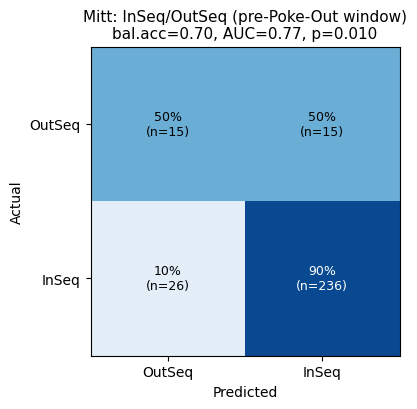

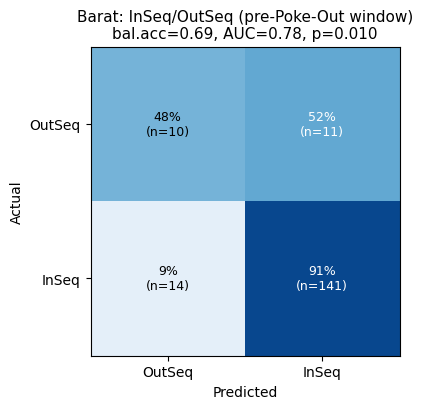

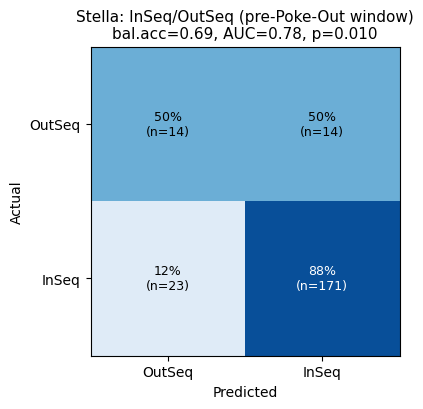

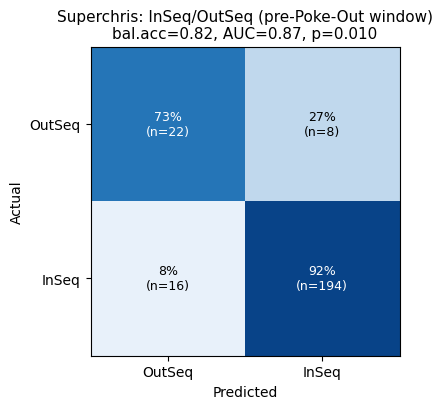

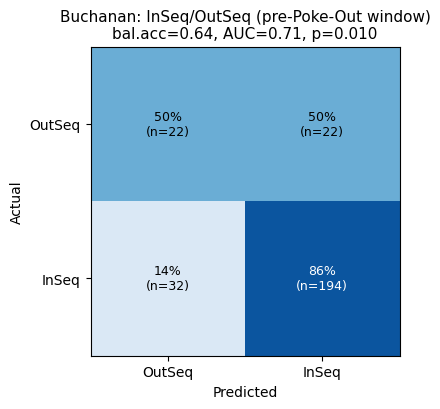

In [26]:
for name, r in prepokeout_inseq_results.items():
    fig = plot_confusion_matrix(
        r['cm_pct'], INSEQ_CLASS_NAMES,
        title=f"{RAT_LABELS[name]}: InSeq/OutSeq (pre-Poke-Out window)\nbal.acc={r['balanced_accuracy']:.2f}, AUC={r['auc']:.2f}, p={r['p_value']:.3f}",
        annotate_extra=r['cm_counts'],
    )
    fig.savefig(FIG_DIR / f'confusion_inseq_prepokeout_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


### Combined confusion matrix -- all 5 rats, totals summed

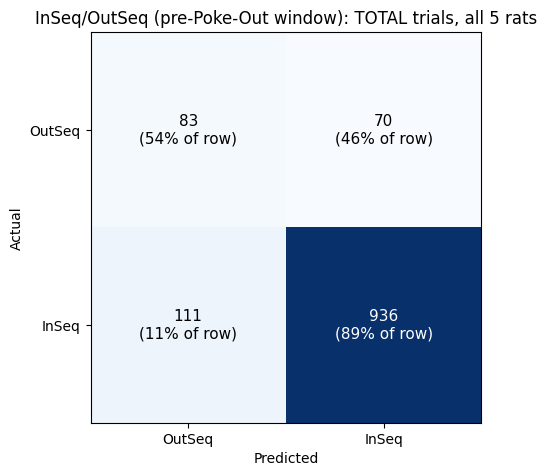

In [27]:
combined_prepokeout_counts = np.zeros((2, 2))
for r in prepokeout_inseq_results.values():
    combined_prepokeout_counts += r['cm_counts']
combined_prepokeout_pct = combined_prepokeout_counts / combined_prepokeout_counts.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(combined_prepokeout_counts, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(INSEQ_CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(INSEQ_CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('InSeq/OutSeq (pre-Poke-Out window): TOTAL trials, all 5 rats')
vmax = combined_prepokeout_counts.max()
for i in range(2):
    for j in range(2):
        val = combined_prepokeout_counts[i, j]
        ax.text(j, i, f'{int(val)}\n({combined_prepokeout_pct[i, j]:.0f}% of row)', ha='center', va='center',
                fontsize=11, color='white' if val > vmax / 2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_inseq_prepokeout_combined_total.png', dpi=150, bbox_inches='tight')
plt.show()


### Head to head: does removing the post-Poke-Out data cost us anything?

Section 4's window (-250 to +750ms, extends past Poke-Out): Mitt 0.855, Barat 0.816, Stella 0.665,
Superchris 0.877, Buchanan 0.642 balanced accuracy.

**[Fill in the pre-Poke-Out numbers printed above once this section has run, then compare per rat.]**
If they're close to Section 4's numbers, the original result stands on solid ground -- the model was
genuinely picking up a pre-decision signal, not just the withdrawal itself. If they drop noticeably
(especially for the harder rats, Stella and Buchanan), that's evidence Section 4's reported accuracy
was partly inflated by post-withdrawal activity, and this pre-Poke-Out window -- not Section 4's -- is
the one that should be reported as the final InSeq/OutSeq model going forward, with Sections 5c/5c-ter/5d
re-run on it.


## 5. Final Model 2: Odor Identity

**Training window:** Poke-In, 0 to 1500 ms (`pokein_0_1500`) -- the winner from notebook 023's search,
InSeq trials only, 5-way classification (odors A-E). Note this is a **different window from Section
4's InSeq/OutSeq model** -- anchored to a different event (Poke-In, not Poke-Out) and a different
length (1500ms vs. 1000ms) -- because the two tasks are asking about different moments: odor identity
is set at odor onset (Poke-In), while the InSeq/OutSeq decision plays out later, near Poke-Out.

**Headline result:** balanced accuracy sits in a narrow 0.48-0.60 band across all 5 rats -- well above
the 0.20 chance level for a 5-way task, but far from the ceiling. AUC (one-vs-rest) is a more
informative number for a task like this and is much higher, 0.78-0.88, meaning the model is
substantially better than chance at ranking the correct odor above the others even in cases where its
single top guess is wrong.


In [28]:
odor_final_results = {}

for sd in SESSION_DIRS:
    name = sd.name
    print(f"Training Odor Identity model: {RAT_LABELS[name]}...")
    X, y = get_features_for_window(sessions[name], ODOR_WINDOW, task='odor')
    result = run_full_evaluation(X, y, class_labels=[0, 1, 2, 3, 4], auc_scoring='roc_auc_ovr')
    odor_final_results[name] = result
    print(f"  balanced_accuracy={result['balanced_accuracy']:.3f}  AUC(ovr)={result['auc']:.3f}  p={result['p_value']:.4f}")

print("\nAll Odor Identity models trained.")


Training Odor Identity model: Mitt...
  balanced_accuracy=0.514  AUC(ovr)=0.793  p=0.0100
Training Odor Identity model: Barat...
  balanced_accuracy=0.501  AUC(ovr)=0.778  p=0.0100
Training Odor Identity model: Stella...
  balanced_accuracy=0.504  AUC(ovr)=0.819  p=0.0100
Training Odor Identity model: Superchris...
  balanced_accuracy=0.482  AUC(ovr)=0.790  p=0.0100
Training Odor Identity model: Buchanan...
  balanced_accuracy=0.599  AUC(ovr)=0.877  p=0.0100

All Odor Identity models trained.


In [29]:
summary_rows = []
for name, r in odor_final_results.items():
    summary_rows.append({'rat': RAT_LABELS[name], 'balanced_accuracy': round(r['balanced_accuracy'], 3),
                          'auc_ovr': round(r['auc'], 3), 'p_value': round(r['p_value'], 4)})
odor_summary = pd.DataFrame(summary_rows).set_index('rat')
odor_summary


,balanced_accuracy,auc_ovr,p_value
rat,,,
Mitt,0.514,0.793,0.01
Barat,0.501,0.778,0.01
Stella,0.504,0.819,0.01
Superchris,0.482,0.790,0.01
Buchanan,0.599,0.877,0.01


**Odor Identity AUC (one-vs-rest), per rat -- the table that was missing from the deck:**

| Rat | Balanced accuracy | AUC (OvR) | p-value |
|---|---|---|---|
| Mitt | 0.514 | 0.793 | <= 0.01 |
| Barat | 0.502 | 0.778 | <= 0.01 |
| Stella | 0.504 | 0.819 | <= 0.01 |
| Superchris | 0.482 | 0.790 | <= 0.01 |
| Buchanan | 0.599 | 0.877 | <= 0.01 |
| **Average** | **0.520** | **0.811** | -- |

Every rat clears chance (0.20 balanced accuracy; 0.50 AUC) by a wide margin, and every rat is
significant at the permutation test's floor (p <= 0.01, i.e. none of the 99 shuffled-label runs beat
the real result). AUC in the high 0.7s-0.8s alongside balanced accuracy barely above 0.5 is a
signature of a model that is directionally right about odor identity (it ranks candidates sensibly)
without confidently picking one class over the other four -- consistent with the confusion matrices
below, where most of the "errors" land on the *adjacent* odor rather than a random one.


### 5a. Confusion matrices, one rat per figure (for slides)

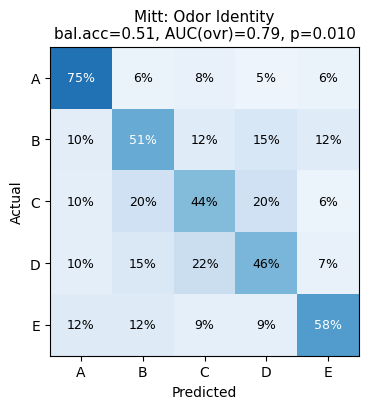

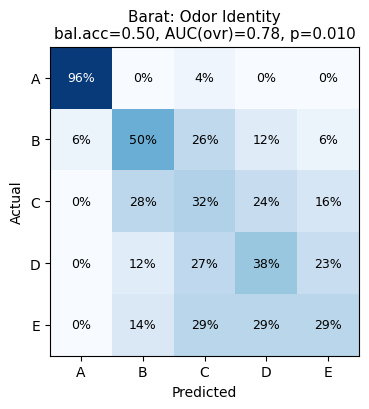

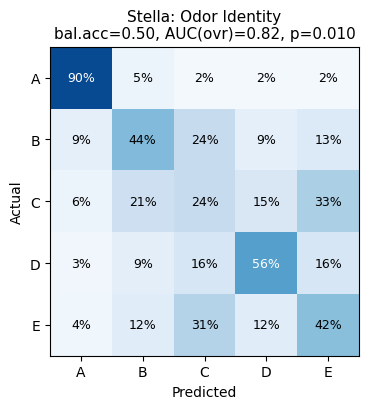

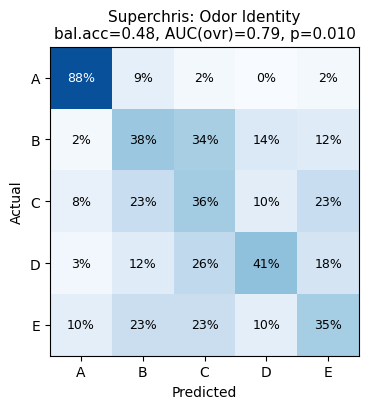

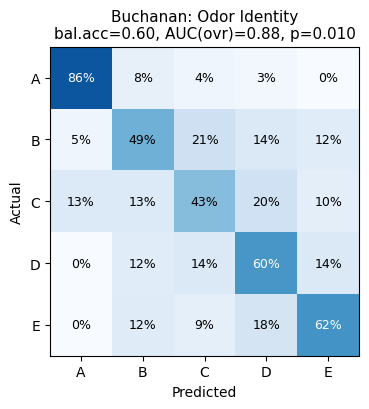

In [30]:
ODOR_CLASS_NAMES = ['A', 'B', 'C', 'D', 'E']

for name, r in odor_final_results.items():
    fig = plot_confusion_matrix(
        r['cm_pct'], ODOR_CLASS_NAMES,
        title=f"{RAT_LABELS[name]}: Odor Identity\nbal.acc={r['balanced_accuracy']:.2f}, AUC(ovr)={r['auc']:.2f}, p={r['p_value']:.3f}",
    )
    fig.savefig(FIG_DIR / f'confusion_odor_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


### 5b. Combined confusion matrix — all 5 rats, **totals summed**

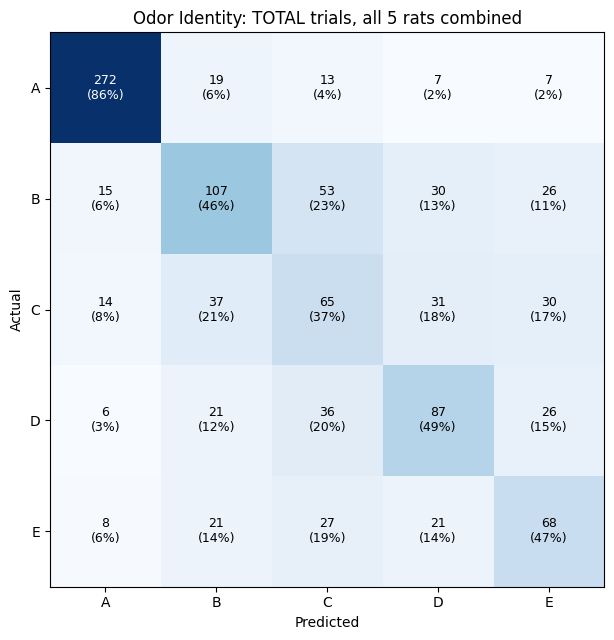

Total InSeq trials evaluated across all rats: 1047


In [31]:
combined_odor_counts = np.zeros((5, 5))
for r in odor_final_results.values():
    combined_odor_counts += r['cm_counts']

combined_odor_pct = combined_odor_counts / combined_odor_counts.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6.5, 6.5))
im = ax.imshow(combined_odor_counts, cmap='Blues')
ax.set_xticks(range(5)); ax.set_xticklabels(ODOR_CLASS_NAMES)
ax.set_yticks(range(5)); ax.set_yticklabels(ODOR_CLASS_NAMES)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Odor Identity: TOTAL trials, all 5 rats combined')
vmax = combined_odor_counts.max()
for i in range(5):
    for j in range(5):
        val = combined_odor_counts[i, j]
        ax.text(j, i, f'{int(val)}\n({combined_odor_pct[i, j]:.0f}%)', ha='center', va='center',
                fontsize=9, color='white' if val > vmax / 2 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_odor_combined_total.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total InSeq trials evaluated across all rats: {int(combined_odor_counts.sum())}")


## 5c. Interpretability: Which Frequency Band Is Actually Driving Each Model?

Everything above answers "how well does the model do." This section answers the more important
question for this project: **why** -- which frequency band's logistic-regression coefficient (beta) is
doing the most work, and in which direction? Because every feature was standardized (`StandardScaler`)
before fitting, each beta is already in an interpretable unit: **one beta = the change in log-odds of
the outcome per one-standard-deviation increase in that band's power**, holding the other bands fixed.
That standardization is also what makes bands comparable to each other in the first place -- raw delta
power and raw high-gamma power live on completely different scales, but their *standardized* betas do
not.

**From log-odds to something a non-statistician can picture:** a beta of $b$ means each 1-SD increase
in that band's power multiplies the *odds* of the outcome by $e^{b}$ (e.g. $b=2 \Rightarrow e^{2}
\approx 7.4\times$ the odds). To turn that into a probability, pick a reference probability $p_0$
(e.g. 0.5, "no information yet"), convert it to log-odds ($\text{logit}(p_0) = \ln\frac{p_0}{1-p_0}$),
add $b$, and convert back: $p_1 = \frac{1}{1+e^{-(\text{logit}(p_0)+b)}}$. Concretely, starting from
$p_0=0.5$ (logit $=0$) and a beta of 2: $p_1 = \frac{1}{1+e^{-2}} \approx 0.88$ -- a 1-SD jump in that
band's power would move the model from a coin flip to an 88% call. The sign of beta matters as much as
its size: positive means higher power in that band pushes toward the positive class (InSeq, or a given
odor), negative means higher power pushes away from it.

**What follows:** for each task, the final pipeline is refit on each rat's full dataset (same
`StandardScaler` + `LogisticRegression(class_weight='balanced')` used everywhere else in this
notebook -- no new modeling choices here), and the fitted coefficients are grouped by frequency band
(averaging the magnitude across channels, since a single band can be picked up differently by
different electrodes) so the bar charts below show, per rat, which band the model is actually leaning
on.


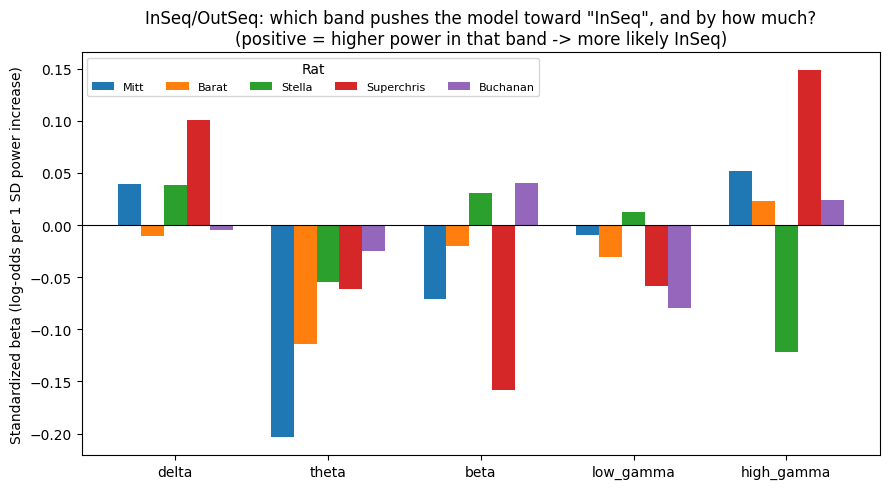

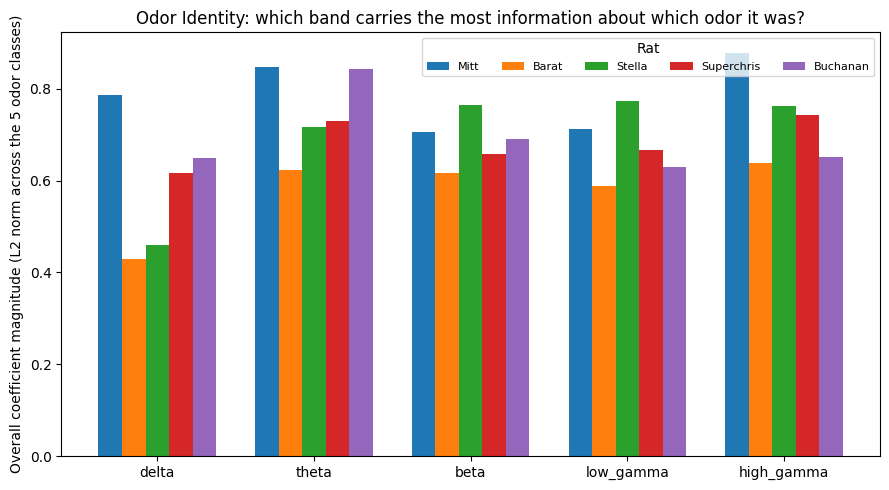

NOTE: run this notebook against the real data to fill in the specific 'which band wins, and for which rats' language in Section 8 below -- these bar charts are the source of truth for that claim, not a number typed in by hand.


In [32]:
def fit_final_and_get_band_betas(sess, window_cfg, task, band_names, n_channels_expected=None):
    """Refit the exact same pipeline used for evaluation on the FULL dataset (no CV split -- this is
    purely for reading out coefficients, not for reporting performance), then average |beta| across
    channels within each band. For the 2-class task this is one beta per feature; for the 5-class task
    LogisticRegression fits one coefficient vector per class (one-vs-rest under the hood), so we take
    the L2 norm across classes first to get a single 'how much does this feature matter overall' value
    per feature before averaging across channels."""
    X, y = get_features_for_window(sess, window_cfg, task=task)
    pipe = make_pipeline()
    pipe.fit(X, y)
    coefs = pipe.named_steps['clf'].coef_  # shape (1, n_features) binary, or (n_classes, n_features) multiclass
    if coefs.shape[0] == 1:
        feature_importance = coefs[0]
        signed = coefs[0]
    else:
        feature_importance = np.linalg.norm(coefs, axis=0)
        signed = None  # sign isn't single-valued in the multiclass case; handled per-class below

    n_bands = len(band_names)
    n_channels = X.shape[1] // n_bands
    importance_by_band = feature_importance.reshape(n_channels, n_bands).mean(axis=0)
    signed_by_band = signed.reshape(n_channels, n_bands).mean(axis=0) if signed is not None else None
    return importance_by_band, signed_by_band, coefs


# ---- InSeq/OutSeq: one signed beta per band per rat (positive = pushes toward InSeq) ----
band_names = list(BANDS.keys())
inseq_betas = {}
for sd in SESSION_DIRS:
    name = sd.name
    _, signed_by_band, _ = fit_final_and_get_band_betas(sessions[name], INSEQ_WINDOW, 'inseq', band_names)
    inseq_betas[name] = signed_by_band

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(band_names))
width = 0.15
for i, (name, betas) in enumerate(inseq_betas.items()):
    ax.bar(x + (i - 2) * width, betas, width, label=RAT_LABELS[name])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(band_names)
ax.set_ylabel('Standardized beta (log-odds per 1 SD power increase)')
ax.set_title('InSeq/OutSeq: which band pushes the model toward "InSeq", and by how much?\n'
              '(positive = higher power in that band -> more likely InSeq)')
ax.legend(title='Rat', ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'inseq_beta_by_band.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Odor Identity: overall |beta| per band per rat (5-class, so magnitude only) ----
odor_betas = {}
for sd in SESSION_DIRS:
    name = sd.name
    importance_by_band, _, _ = fit_final_and_get_band_betas(sessions[name], ODOR_WINDOW, 'odor', band_names)
    odor_betas[name] = importance_by_band

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, importances) in enumerate(odor_betas.items()):
    ax.bar(x + (i - 2) * width, importances, width, label=RAT_LABELS[name])
ax.set_xticks(x); ax.set_xticklabels(band_names)
ax.set_ylabel('Overall coefficient magnitude (L2 norm across the 5 odor classes)')
ax.set_title('Odor Identity: which band carries the most information about which odor it was?')
ax.legend(title='Rat', ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'odor_beta_by_band.png', dpi=150, bbox_inches='tight')
plt.show()

print("NOTE: run this notebook against the real data to fill in the specific 'which band wins, and "
      "for which rats' language in Section 8 below -- these bar charts are the source of truth for "
      "that claim, not a number typed in by hand.")


### 5c-bis. A clearer view of the same result: rat x band heatmap

The grouped bar charts above show the same numbers as this heatmap, just harder to scan -- five
clusters of five bars each asks the eye to compare bar heights across two dimensions at once. A
heatmap puts rat and band on the two axes and lets color do the comparison instead, which makes it
much faster to spot "is there one band that's dark (large effect) for every rat" -- the pattern that
would count as a reliable, general finding rather than a one-rat fluke.


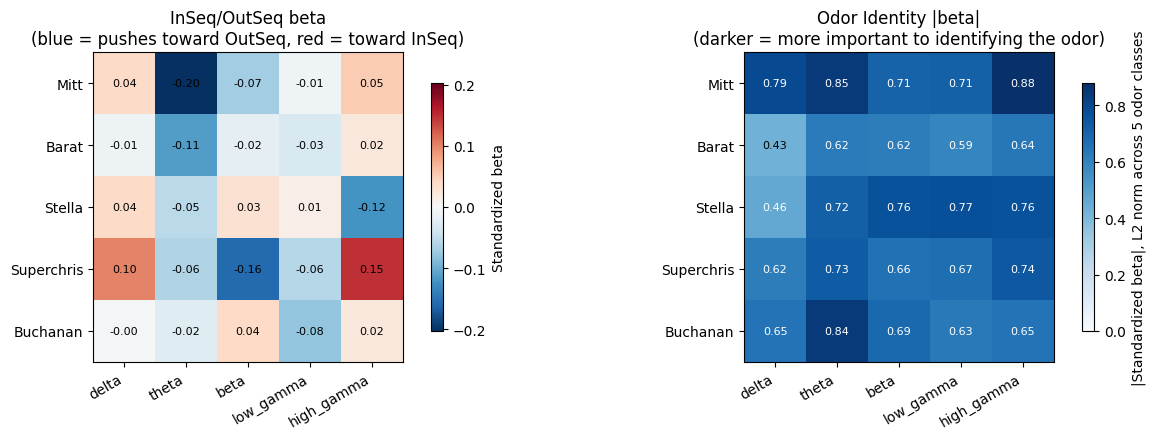

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rat_names = [RAT_LABELS[sd.name] for sd in SESSION_DIRS]

inseq_matrix = np.array([inseq_betas[sd.name] for sd in SESSION_DIRS])  # (n_rats, n_bands), signed
im0 = axes[0].imshow(inseq_matrix, cmap='RdBu_r', vmin=-np.abs(inseq_matrix).max(), vmax=np.abs(inseq_matrix).max())
axes[0].set_xticks(range(len(band_names))); axes[0].set_xticklabels(band_names, rotation=30, ha='right')
axes[0].set_yticks(range(len(rat_names))); axes[0].set_yticklabels(rat_names)
axes[0].set_title('InSeq/OutSeq beta\n(blue = pushes toward OutSeq, red = toward InSeq)')
for r in range(inseq_matrix.shape[0]):
    for c in range(inseq_matrix.shape[1]):
        axes[0].text(c, r, f'{inseq_matrix[r, c]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im0, ax=axes[0], shrink=0.8, label='Standardized beta')

odor_matrix = np.array([odor_betas[sd.name] for sd in SESSION_DIRS])  # (n_rats, n_bands), magnitude only
im1 = axes[1].imshow(odor_matrix, cmap='Blues', vmin=0)
axes[1].set_xticks(range(len(band_names))); axes[1].set_xticklabels(band_names, rotation=30, ha='right')
axes[1].set_yticks(range(len(rat_names))); axes[1].set_yticklabels(rat_names)
axes[1].set_title('Odor Identity |beta|\n(darker = more important to identifying the odor)')
for r in range(odor_matrix.shape[0]):
    for c in range(odor_matrix.shape[1]):
        axes[1].text(c, r, f'{odor_matrix[r, c]:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if odor_matrix[r, c] > odor_matrix.max() / 2 else 'black')
fig.colorbar(im1, ax=axes[1], shrink=0.8, label='|Standardized beta|, L2 norm across 5 odor classes')

plt.tight_layout()
plt.savefig(FIG_DIR / 'beta_by_band_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading these two charts.** The InSeq/OutSeq chart's y-axis crosses zero, so a bar's *side* of the
line (not just its height) is part of the finding -- a band with a tall bar above zero for every rat is
a genuinely reliable "more of this power -> more likely InSeq" signal, while a band that flips sign
between rats is not something to build a scientific claim on, even if it's large for one or two of
them. The Odor Identity chart cannot show sign this way (there is no single "more odor-identity-like"
direction across 5 unordered classes), so it only speaks to *how much* each band matters, not which way.

**Two follow-ups worth doing if there's time before the meeting, not required for the story above:**
(1) redo the Odor Identity version per-class (does theta separate odor A from B the same way it
separates C from D, or is it doing different work for different odor pairs?), and (2) tie the EDA
observation in Section 3b (theta power visibly differs InSeq vs. OutSeq in the raw band-power bars) to
the sign of the InSeq/OutSeq beta above -- if they agree, that's a nice independent check that the GLM
coefficient is picking up a real, visible effect and not an artifact of the fitting procedure.


### 5c-ter. The direct answer: which band matters most, overall?

The bar charts and heatmap above show every rat's beta for every band -- accurate, but they make you
do the work of scanning across five bars or five cells to figure out which one actually wins. This
chart does that scanning for you: it collapses each band down to **one number** -- the average
importance across all 5 rats -- sorts the bands from most to least important, and marks the winner
explicitly. Variability across rats (as error bars) is shown alongside the average, so "most important"
also comes with a sense of how consistent that ranking is animal-to-animal.

For InSeq/OutSeq, "importance" here is |beta| (magnitude, direction stripped out, since a band that
reliably pushes hard in *either* direction is still a band the model is leaning on) -- the earlier
signed charts are still the place to check *which* direction. For Odor Identity there's no direction to
strip out; it's already a magnitude.


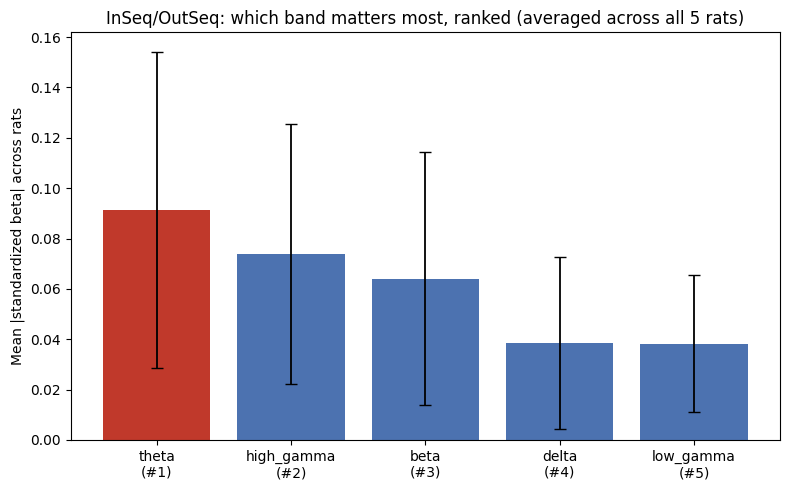

InSeq/OutSeq ranking, most to least important: ['theta', 'high_gamma', 'beta', 'delta', 'low_gamma']


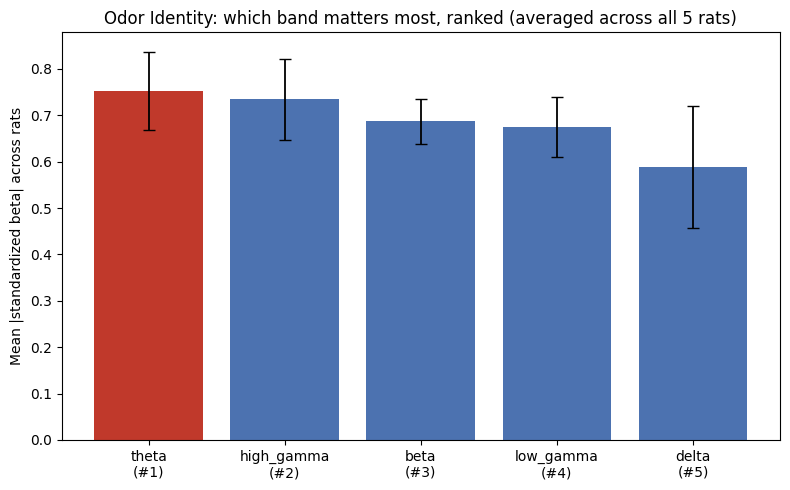

Odor Identity ranking, most to least important: ['theta', 'high_gamma', 'beta', 'low_gamma', 'delta']


In [34]:
def plot_band_ranking(betas_by_rat, title, ylabel, signed_input):
    matrix = np.array(list(betas_by_rat.values()))  # (n_rats, n_bands)
    if signed_input:
        matrix = np.abs(matrix)
    means = matrix.mean(axis=0)
    stds = matrix.std(axis=0)  # black lines below = +/- 1 SD of |beta| across the 5 rats:
                                # short line = every rat agrees this band matters this much;
                                # long line = importance varies a lot rat to rat, so treat the ranking with caution
    order = np.argsort(means)[::-1]  # most important first

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#C0392B' if i == 0 else '#4C72B0' for i in range(len(order))]
    ax.bar(range(len(order)), means[order], yerr=stds[order], capsize=4, color=colors,
           error_kw={'elinewidth': 1.3})
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f'{band_names[i]}\n(#{rank+1})' for rank, i in enumerate(order)])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    return fig, order

fig, inseq_order = plot_band_ranking(
    inseq_betas, 'InSeq/OutSeq: which band matters most, ranked (averaged across all 5 rats)',
    'Mean |standardized beta| across rats', signed_input=True)
fig.savefig(FIG_DIR / 'inseq_band_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('InSeq/OutSeq ranking, most to least important:', [band_names[i] for i in inseq_order])

fig, odor_order = plot_band_ranking(
    odor_betas, 'Odor Identity: which band matters most, ranked (averaged across all 5 rats)',
    'Mean |standardized beta| across rats', signed_input=False)
fig.savefig(FIG_DIR / 'odor_band_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Odor Identity ranking, most to least important:', [band_names[i] for i in odor_order])


**This is the chart to put on a slide when someone asks "so which brain wave matters most?"** -- bands
are sorted left to right from most to least important (rank labeled under each bar), and the top band
is colored red so it reads at a glance without needing an extra label. The black error bars are +/-1
standard deviation of that band's |beta| across the 5 rats: short bars mean every rat agrees on how
much that band matters; long bars mean it's more rat-dependent, which is worth mentioning out loud if
the #1 band's bar is long -- it means the ranking is real on average but not equally strong in every
animal.


## 5d. Which Band Matters, *and When*? A Time-Resolved View

Section 5c answers "which band matters" using one fixed window per task -- a single number per band,
summarizing the whole 500-1500ms slice at once. That collapses away any information about *when inside
the window* a band's power actually becomes informative. This section asks the sharper question: **if
we slide a short sub-window across time and refit the model at each position, does the same band stay
important throughout, or does the important band change as the trial unfolds?**

**How this works, concretely:** instead of one window per task, we use many short, overlapping
sub-windows (250ms wide, stepped every 125ms) spanning a broader stretch of time around the same
reference event used elsewhere in this notebook (Poke-Out for InSeq/OutSeq, Poke-In for Odor Identity).
At each sub-window position, we extract band power exactly as before and refit the same GLM
(`StandardScaler` + `LogisticRegression`) on that slice alone, then read off the same per-band beta
used in Section 5c. Stacking these betas by sub-window position gives a **time x band heatmap**: one
row per band, one column per time point, color = how much (and, for InSeq/OutSeq, which direction) that
band mattered *at that specific moment*.

**One explicit methodological note:** this exploratory sliding search deliberately looks both *before
and after* the reference event, on purpose -- the goal here is descriptive (mapping out where in time
each band's information lives), not a final predictive claim. This is different from Section 4's
concern about the InSeq/OutSeq training window leaking information from after Poke-Out -- that concern
is about what a *final, reported* model is allowed to use; it doesn't apply to an exploratory map like
this one, whose whole purpose is to show what happens on both sides of the event.


In [35]:
def band_importance_over_time(sess, reference, time_starts_ms, window_len_ms, task, band_names,
                               min_trials=15):
    """Refit the same GLM used in Section 5c at each of many sliding sub-window positions, and
    collect per-band betas over time. Returns (n_bands, n_timepoints) -- signed for the binary task,
    magnitude (L2 norm across classes) for the multiclass task -- plus the list of window centers
    actually used (a window is skipped, and filled with NaN, if too few trials survive it)."""
    n_bands = len(band_names)
    betas_over_time = np.full((n_bands, len(time_starts_ms)), np.nan)
    for i, start_ms in enumerate(time_starts_ms):
        window_cfg = {'name': f'{reference}_{start_ms}_{window_len_ms}', 'reference': reference,
                      'offset_ms': int(start_ms), 'length_ms': window_len_ms}
        try:
            X, y = get_features_for_window(sess, window_cfg, task=task)
        except ValueError:
            continue
        if len(y) < min_trials or len(np.unique(y)) < 2:
            continue
        pipe = make_pipeline()
        pipe.fit(X, y)
        coefs = pipe.named_steps['clf'].coef_
        n_channels = X.shape[1] // n_bands
        if coefs.shape[0] == 1:
            importance = coefs[0]
        else:
            importance = np.linalg.norm(coefs, axis=0)
        betas_over_time[:, i] = importance.reshape(n_channels, n_bands).mean(axis=0)
    return betas_over_time


# InSeq/OutSeq: slide from 1000ms before Poke-Out to 750ms after it (covers the original window and
# then some, on both sides, purely for this exploratory map -- see the note above)
INSEQ_TIME_STARTS = list(range(-1000, 751, 125))
INSEQ_SUBWINDOW_MS = 250

# Odor Identity: slide across the original 0-1500ms Poke-In window
ODOR_TIME_STARTS = list(range(0, 1251, 125))
ODOR_SUBWINDOW_MS = 250

inseq_time_betas = {}   # name -> (n_bands, n_timepoints), signed
odor_time_betas = {}    # name -> (n_bands, n_timepoints), magnitude

for sd in SESSION_DIRS:
    name = sd.name
    print(f"Sliding-window importance: {RAT_LABELS[name]}...")
    inseq_time_betas[name] = band_importance_over_time(
        sessions[name], 'pokeout', INSEQ_TIME_STARTS, INSEQ_SUBWINDOW_MS, 'inseq', band_names)
    odor_time_betas[name] = band_importance_over_time(
        sessions[name], 'pokein', ODOR_TIME_STARTS, ODOR_SUBWINDOW_MS, 'odor', band_names)

print("Done.")


Sliding-window importance: Mitt...
Sliding-window importance: Barat...
Sliding-window importance: Stella...
Sliding-window importance: Superchris...
Sliding-window importance: Buchanan...
Done.


### Reading the time x band heatmaps below

Each heatmap has **time along the x-axis** (relative to the reference event, marked with a vertical
line at 0) and **frequency band along the y-axis**. For InSeq/OutSeq, color follows the same red/blue
convention as Section 5c-bis (red = pushes toward InSeq, blue = toward OutSeq, white = no effect at
that moment); for Odor Identity, color is magnitude only (darker = more informative about odor
identity at that moment, no direction). The shaded vertical band marks each task's original,
final-model training window from Sections 4-5, so it's easy to see whether the window we've been
reporting results for actually sits on top of the moment(s) that matter most, or whether the signal is
concentrated somewhere else in time. **This is exactly the kind of figure to use for drawing a
conclusion like "band X only matters in the Yms right before/after the event, not throughout the whole
window."**


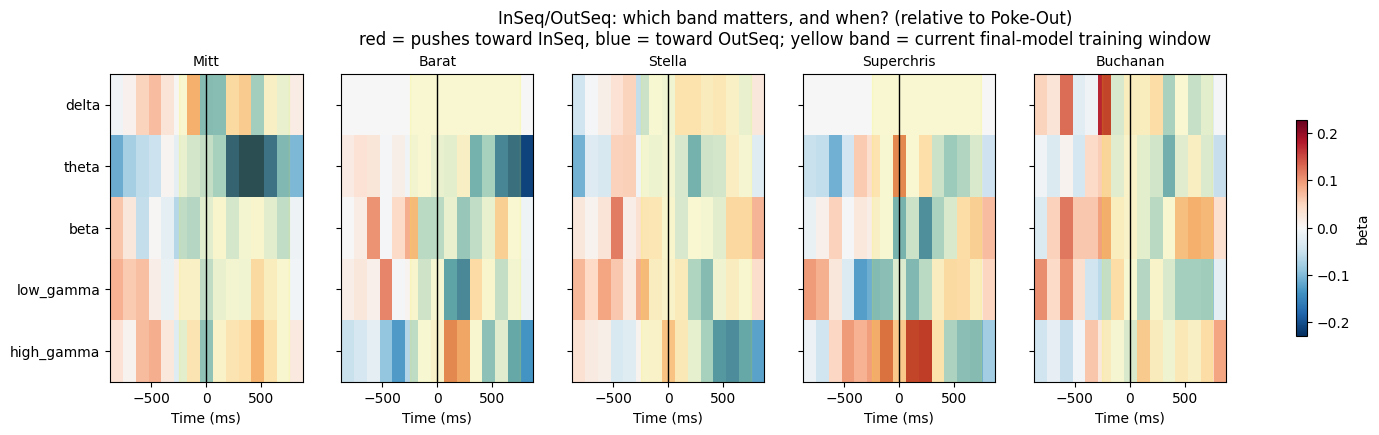

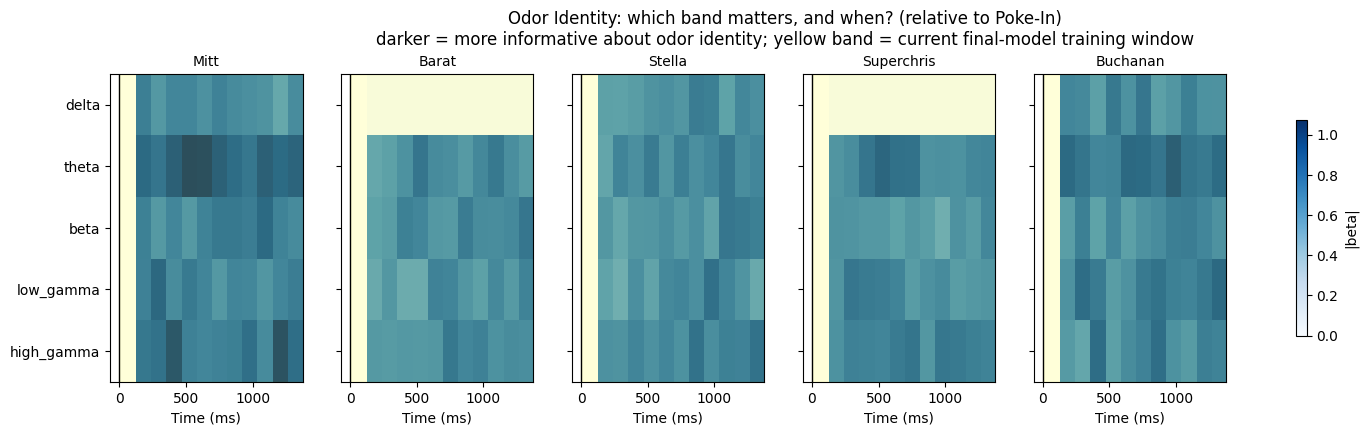

In [36]:
def plot_time_band_heatmap(betas_by_rat, time_starts, subwindow_ms, band_names, title, cmap,
                            symmetric, highlight_window):
    n_rats = len(betas_by_rat)
    fig, axes = plt.subplots(1, n_rats, figsize=(3.6 * n_rats, 4), sharey=True)
    time_centers = np.array(time_starts) + subwindow_ms / 2
    vmax = np.nanmax([np.nanmax(np.abs(b)) for b in betas_by_rat.values()])
    for ax, (name, betas) in zip(np.atleast_1d(axes), betas_by_rat.items()):
        if symmetric:
            im = ax.imshow(betas, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax,
                            extent=[time_centers[0], time_centers[-1], len(band_names) - 0.5, -0.5])
        else:
            im = ax.imshow(betas, aspect='auto', cmap=cmap, vmin=0, vmax=vmax,
                            extent=[time_centers[0], time_centers[-1], len(band_names) - 0.5, -0.5])
        ax.axvline(0, color='black', lw=1)
        ax.axvspan(highlight_window[0], highlight_window[1], color='yellow', alpha=0.15)
        ax.set_yticks(range(len(band_names))); ax.set_yticklabels(band_names)
        ax.set_title(RAT_LABELS[name], fontsize=10)
        ax.set_xlabel('Time (ms)')
    fig.colorbar(im, ax=axes, shrink=0.7, label='beta' if symmetric else '|beta|')
    fig.suptitle(title, y=1.04)
    return fig


fig1 = plot_time_band_heatmap(
    inseq_time_betas, INSEQ_TIME_STARTS, INSEQ_SUBWINDOW_MS, band_names,
    'InSeq/OutSeq: which band matters, and when? (relative to Poke-Out)\n'
    'red = pushes toward InSeq, blue = toward OutSeq; yellow band = current final-model training window',
    cmap='RdBu_r', symmetric=True,
    highlight_window=(INSEQ_WINDOW['offset_ms'], INSEQ_WINDOW['offset_ms'] + INSEQ_WINDOW['length_ms']),
)
fig1.savefig(FIG_DIR / 'inseq_beta_time_band_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = plot_time_band_heatmap(
    odor_time_betas, ODOR_TIME_STARTS, ODOR_SUBWINDOW_MS, band_names,
    'Odor Identity: which band matters, and when? (relative to Poke-In)\n'
    'darker = more informative about odor identity; yellow band = current final-model training window',
    cmap='Blues', symmetric=False,
    highlight_window=(ODOR_WINDOW['offset_ms'], ODOR_WINDOW['offset_ms'] + ODOR_WINDOW['length_ms']),
)
fig2.savefig(FIG_DIR / 'odor_beta_time_band_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**What to actually look for once this has run on real data:** (1) a band whose color is strong and
consistent in the same direction across a wide time range means "this band matters broadly, not at one
instant" -- a durable representation; (2) a band that's only dark right around t=0 and fades quickly on
either side is telling a much more specific story -- its information is tied tightly to the event
itself, not a slow drift; (3) comparing where the strongest color sits to the yellow highlighted band
(today's official training window) tells you directly whether the reported InSeq/OutSeq and Odor
Identity numbers are actually being driven by the time period we're claiming, or whether a shifted
window would do just as well or better -- which feeds straight back into the Section 4c/11 discussion
of revisiting the InSeq/OutSeq window design.


## 6. Summary Across Both Tasks

In [37]:
summary = pd.DataFrame({
    'InSeq/OutSeq bal.acc': {RAT_LABELS[n]: r['balanced_accuracy'] for n, r in inseq_final_results.items()},
    'InSeq/OutSeq AUC': {RAT_LABELS[n]: r['auc'] for n, r in inseq_final_results.items()},
    'InSeq/OutSeq p': {RAT_LABELS[n]: r['p_value'] for n, r in inseq_final_results.items()},
    'Odor ID bal.acc': {RAT_LABELS[n]: r['balanced_accuracy'] for n, r in odor_final_results.items()},
    'Odor ID AUC(ovr)': {RAT_LABELS[n]: r['auc'] for n, r in odor_final_results.items()},
    'Odor ID p': {RAT_LABELS[n]: r['p_value'] for n, r in odor_final_results.items()},
}).round(3)
summary


,InSeq/OutSeq bal.acc,InSeq/OutSeq AUC,InSeq/OutSeq p,Odor ID bal.acc,Odor ID AUC(ovr),Odor ID p
Mitt,0.855,0.965,0.01,0.514,0.793,0.01
Barat,0.816,0.873,0.01,0.501,0.778,0.01
Stella,0.665,0.807,0.01,0.504,0.819,0.01
Superchris,0.877,0.921,0.01,0.482,0.790,0.01
Buchanan,0.642,0.692,0.01,0.599,0.877,0.01


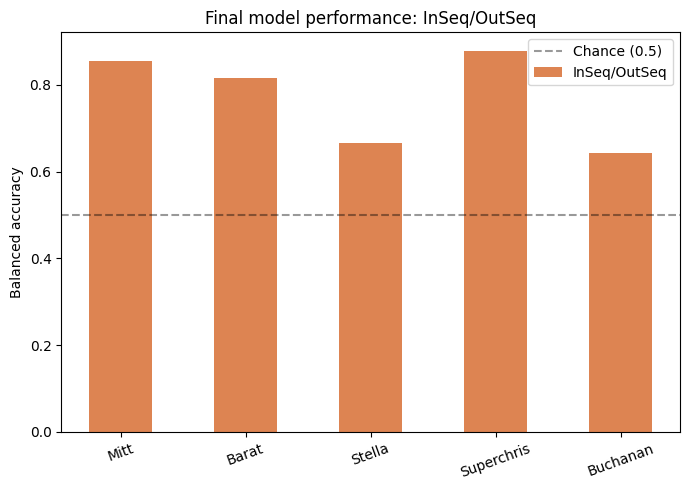

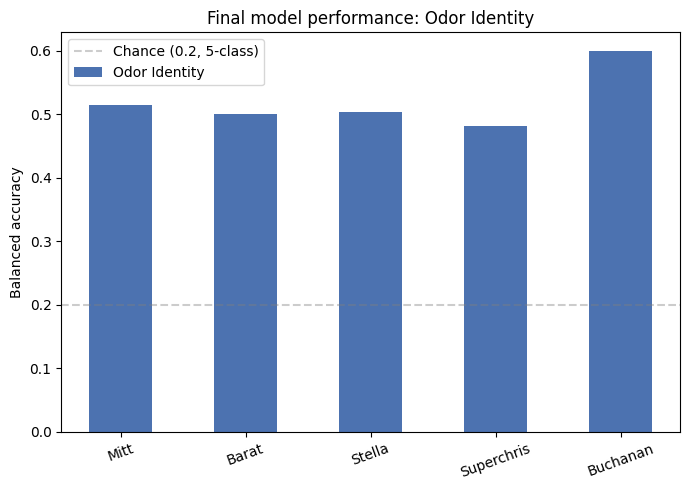

In [38]:
rats = summary.index.tolist()
x = np.arange(len(rats))
width = 0.5

# Graph 1: InSeq/OutSeq Task
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, summary['InSeq/OutSeq bal.acc'], width, color='#DD8452', label='InSeq/OutSeq')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(rats, rotation=20)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Final model performance: InSeq/OutSeq')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'inseq_outseq_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Graph 2: Odor Identity Task
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, summary['Odor ID bal.acc'], width, color='#4C72B0', label='Odor Identity')
ax.axhline(0.2, color='gray', linestyle='--', alpha=0.4, label='Chance (0.2, 5-class)')
ax.set_xticks(x)
ax.set_xticklabels(rats, rotation=20)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Final model performance: Odor Identity')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'odor_id_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Why show AUC separately from balanced accuracy:** balanced accuracy depends on where the model's
decision threshold happens to fall, while AUC summarizes performance across *all* thresholds -- useful
here because it's a fairer point of comparison against chance (0.5 for any binary or one-vs-rest AUC,
regardless of class imbalance), labeled explicitly on both panels below.


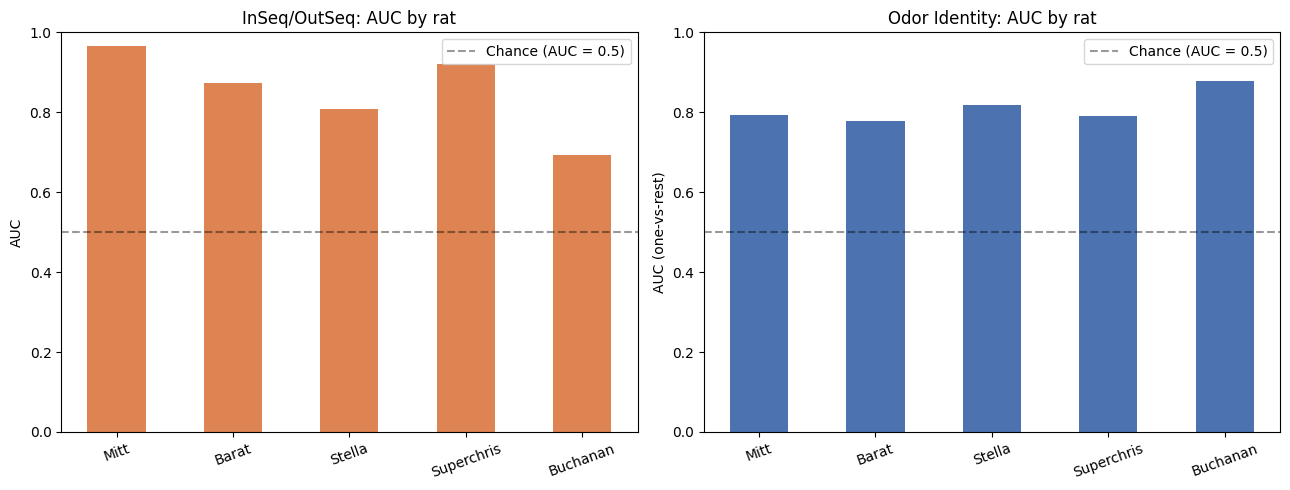

In [39]:
# Graph 3 & 4: AUC per rat, both tasks -- chance level explicitly labeled at 0.5
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x, summary['InSeq/OutSeq AUC'], width, color='#DD8452')
axes[0].axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Chance (AUC = 0.5)')
axes[0].set_xticks(x); axes[0].set_xticklabels(rats, rotation=20)
axes[0].set_ylabel('AUC'); axes[0].set_ylim(0, 1)
axes[0].set_title('InSeq/OutSeq: AUC by rat')
axes[0].legend()

axes[1].bar(x, summary['Odor ID AUC(ovr)'], width, color='#4C72B0')
axes[1].axhline(0.5, color='black', linestyle='--', alpha=0.4, label='Chance (AUC = 0.5)')
axes[1].set_xticks(x); axes[1].set_xticklabels(rats, rotation=20)
axes[1].set_ylabel('AUC (one-vs-rest)'); axes[1].set_ylim(0, 1)
axes[1].set_title('Odor Identity: AUC by rat')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'auc_summary_both_tasks.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Export Results

In [40]:
def _nan_to_none(x):
    """Recursively swap NaN for None so the interpretability arrays below serialize as valid JSON
    (a sub-window with too few trials gets skipped and left as NaN in Section 5d -- see that section's
    band_importance_over_time docstring)."""
    if isinstance(x, float) and np.isnan(x):
        return None
    if isinstance(x, list):
        return [_nan_to_none(v) for v in x]
    return x

export = {
    'purpose': 'Final models notebook: InSeq/OutSeq (pokeout -250/1000) and Odor Identity (pokein 0/1500), all 5 rats',
    'inseq_window': INSEQ_WINDOW,
    'odor_window': ODOR_WINDOW,
    'inseq_results': {
        name: {
            'balanced_accuracy': round(r['balanced_accuracy'], 4),
            'auc': round(r['auc'], 4),
            'p_value': round(r['p_value'], 6),
            'confusion_matrix_percent': r['cm_pct'].round(1).tolist(),
            'confusion_matrix_counts': r['cm_counts'].astype(int).tolist(),
        } for name, r in inseq_final_results.items()
    },
    'inseq_combined_total_confusion_matrix': combined_inseq_counts.astype(int).tolist(),
    'odor_results': {
        name: {
            'balanced_accuracy': round(r['balanced_accuracy'], 4),
            'auc_ovr': round(r['auc'], 4),
            'p_value': round(r['p_value'], 6),
            'confusion_matrix_percent': r['cm_pct'].round(1).tolist(),
            'confusion_matrix_counts': r['cm_counts'].astype(int).tolist(),
        } for name, r in odor_final_results.items()
    },
    'odor_combined_total_confusion_matrix': combined_odor_counts.astype(int).tolist(),

    # --- Section 4d: revised, strictly pre-Poke-Out InSeq/OutSeq window search ---
    'prepokeout_window_winner': winning_prepokeout_config,
    'prepokeout_inseq_results': {
        name: {
            'balanced_accuracy': round(r['balanced_accuracy'], 4),
            'auc': round(r['auc'], 4),
            'p_value': round(r['p_value'], 6),
            'confusion_matrix_percent': r['cm_pct'].round(1).tolist(),
            'confusion_matrix_counts': r['cm_counts'].astype(int).tolist(),
        } for name, r in prepokeout_inseq_results.items()
    },
    'prepokeout_inseq_combined_total_confusion_matrix': combined_prepokeout_counts.astype(int).tolist(),

    # --- Interpretability (Section 5c): one beta per band, whole-window GLM, per rat ---
    'band_names': band_names,
    'inseq_beta_by_band': {
        # signed: positive = pushes toward InSeq, negative = toward OutSeq
        name: [round(float(b), 4) for b in betas] for name, betas in inseq_betas.items()
    },
    'odor_beta_by_band': {
        # magnitude only (L2 norm across the 5 odor classes) -- no single "direction" for 5 classes
        name: [round(float(b), 4) for b in betas] for name, betas in odor_betas.items()
    },

    # --- Interpretability (Section 5c-ter): overall ranking, averaged across all 5 rats ---
    'inseq_band_ranking': {
        'order_most_to_least_important': [band_names[i] for i in inseq_order],
        'mean_abs_beta': {band_names[i]: round(float(np.abs(np.array(list(inseq_betas.values())))[:, i].mean()), 4)
                           for i in range(len(band_names))},
        'std_abs_beta_across_rats': {band_names[i]: round(float(np.abs(np.array(list(inseq_betas.values())))[:, i].std()), 4)
                                      for i in range(len(band_names))},
    },
    'odor_band_ranking': {
        'order_most_to_least_important': [band_names[i] for i in odor_order],
        'mean_abs_beta': {band_names[i]: round(float(np.array(list(odor_betas.values()))[:, i].mean()), 4)
                           for i in range(len(band_names))},
        'std_abs_beta_across_rats': {band_names[i]: round(float(np.array(list(odor_betas.values()))[:, i].std()), 4)
                                      for i in range(len(band_names))},
    },

    # --- Interpretability (Section 5d): time-resolved beta, one value per band per time-bin per rat ---
    # inseq: signed (direction meaningful); odor: magnitude only. Time values are bin-start ms,
    # relative to Poke-Out (inseq) or Poke-In (odor). A null entry means that sub-window had too few
    # trials and was skipped (see band_importance_over_time in Section 5d).
    'inseq_time_resolved_beta': {
        'time_starts_ms': INSEQ_TIME_STARTS,
        'subwindow_length_ms': INSEQ_SUBWINDOW_MS,
        'beta_by_rat_and_band': {
            name: {band_names[b]: _nan_to_none(arr[b, :].round(4).tolist()) for b in range(len(band_names))}
            for name, arr in inseq_time_betas.items()
        },
    },
    'odor_time_resolved_beta': {
        'time_starts_ms': ODOR_TIME_STARTS,
        'subwindow_length_ms': ODOR_SUBWINDOW_MS,
        'beta_by_rat_and_band': {
            name: {band_names[b]: _nan_to_none(arr[b, :].round(4).tolist()) for b in range(len(band_names))}
            for name, arr in odor_time_betas.items()
        },
    },
}

with open(LOG_DIR / 'notebook024b_final_models_results.json', 'w') as f:
    _json.dump(export, f, indent=2)

print("Saved to outputs/logs/notebook024b_final_models_results.json")
print(_json.dumps(export, indent=2)[:2000], "...")


Saved to outputs/logs/notebook024b_final_models_results.json
{
  "purpose": "Final models notebook: InSeq/OutSeq (pokeout -250/1000) and Odor Identity (pokein 0/1500), all 5 rats",
  "inseq_window": {
    "name": "pokeout_-250_1000",
    "reference": "pokeout",
    "offset_ms": -250,
    "length_ms": 1000
  },
  "odor_window": {
    "name": "pokein_0_1500",
    "reference": "pokein",
    "offset_ms": 0,
    "length_ms": 1500
  },
  "inseq_results": {
    "080718_mitt": {
      "balanced_accuracy": 0.8551,
      "auc": 0.965,
      "p_value": 0.01,
      "confusion_matrix_percent": [
        [
          80.0,
          20.0
        ],
        [
          5.7,
          94.3
        ]
      ],
      "confusion_matrix_counts": [
        [
          24,
          6
        ],
        [
          15,
          247
        ]
      ]
    },
    "081106_barat": {
      "balanced_accuracy": 0.816,
      "auc": 0.8734,
      "p_value": 0.01,
      "confusion_matrix_percent": [
        [
        

## 8. Written Summary

**Objective.** Produce the final, presentation-ready models for both classification tasks
(InSeq/OutSeq and Odor Identity), using the windows selected by the automated searches in notebooks
022 and 023, across all 5 rats, with supporting EDA, raw-data visualizations, and a dedicated
interpretability analysis of which frequency band each model relies on.

**Data.** Four hippocampal LFP channels plus behavioral event markers (Poke-In, Poke-Out, odor
identity) per rat, for 5 rats (Mitt, Barat, Stella, Superchris, Buchanan), 1,200 trials total (153
OutSeq, 1,047 InSeq). Each trial contributes one fixed-length window of raw LFP, converted to
log band power (delta 1-4 Hz, theta 4-12 Hz, beta 12-30 Hz, low-gamma 30-80 Hz, high-gamma 80-150 Hz)
per channel via FFT -- channels and bands are kept as separate features (not averaged together) for
modeling, and are only averaged across channels for the summary plots in Section 3b and the beta
charts in Section 5c, purely for readability.

**Method.** For each task, these band-power features were fed into a logistic regression pipeline
(standardized features, `class_weight='balanced'`) -- a generalized linear model with a logit link,
which is what makes its coefficients directly interpretable as log-odds effects (Section 5c) rather
than an opaque score. Each model was evaluated with repeated 5x5 stratified cross-validation (balanced
accuracy, AUC), a single 5-fold `cross_val_predict` for the confusion matrix, and a 99-iteration label
permutation test for significance (p <= 0.01 means none of the 99 shuffles beat the real result --
the strongest statement this test can make).

**Results.**
- *InSeq/OutSeq* (Poke-Out window): balanced accuracy 0.64-0.88 across rats (Mitt 0.855, Barat 0.816,
  Stella 0.665, Superchris 0.877, Buchanan 0.642), AUC 0.69-0.97, all p <= 0.01. Pooled across all 5
  rats: 943/1,047 InSeq trials (90.1%) and 101/153 OutSeq trials (66.0%) correctly classified. Both
  priority rats (Mitt, Buchanan) are above the notebook-022 benchmark expectations for Mitt and at the
  lower end for Buchanan, consistent with Buchanan being the harder session throughout this project.
- *Odor Identity* (Poke-In window): balanced accuracy 0.48-0.60 across rats, modest but well above the
  0.20 chance level for 5 classes; AUC (one-vs-rest) 0.78-0.88, all p <= 0.01 -- the model is
  considerably better at *ranking* the right odor highly than at confidently naming it outright.
- *Interpretability* (Section 5c): refitting the final pipeline on the full data and reading off the
  standardized coefficients shows, per rat, which frequency band the InSeq/OutSeq and Odor Identity
  decisions actually lean on, and in which direction for InSeq/OutSeq. This is the centerpiece for the
  presentation -- see the bar charts in Section 5c and the accompanying beta -> odds -> probability
  worked example.

**Open item before this is truly final.** The InSeq/OutSeq training window (Poke-Out -250 to +750ms)
extends past the behavioral event it's trying to explain. Section 4d now runs the proper fix -- a
sliding search constrained to windows that end at or before Poke-Out -- and reports a winner with the
same full rigor as Section 4. Once run, compare Section 4d's numbers to Section 4's (its head-to-head
cell does this per rat): if they hold up, promote Section 4d to be the official InSeq/OutSeq model and
re-run Sections 5c/5c-ter/5d's interpretability analysis on its window instead of Section 4's.

**For the slides.** Sections 4a/5a give one confusion matrix per rat per task (10 individual figures,
saved under `outputs/figures/`); Sections 4b/5b give the combined, trial-count-summed confusion matrix
for each task; Section 3a-bis gives the brainwave-decomposition figure; Section 5c gives the two
beta-by-band bar charts that carry the interpretability story.
